# Toronto Municipal Campaign Finance: An Exploratory Story Search

**Scope.** This notebook explores campaign-contribution data from the 2022 Toronto City Council
election and the 2023 Toronto mayoral by-election, alongside 2021 census-tract demographics, to
look for **compelling, defensible angles for a public-facing data story** about who funds
municipal politics in Toronto, where that money comes from, and how it relates to candidates
contesting Toronto again in **2026**.

This is exploratory work, not a finished analysis. The goal is to try several promising
directions, be honest about which ones the data actually supports, and flag the ones with real
story potential as we go (look for **"Story potential"** call-outs and the **"Data-story
potential"** subsections at the end of each part).

**What this notebook does *not* do:**
- It does not save any files. Every table, geodataframe, and figure is produced in memory and
  displayed inline.
- It does not infer anything about individual donors from neighbourhood-level census data
  (see the ecological-inference caveat repeated throughout Part 5).
- It does not treat any 2026 candidate list as final — nominations are still open as of
  **August 17, 2026**.

**Data used**
| Source | What it is |
|---|---|
| `data/campaign_finance/contribution-search-results-2022.xls` | All 2022 Toronto municipal contributions (council, mayor, school board, third-party advertisers) — we keep only **council candidates** |
| `data/campaign_finance/contribution-search-results-2023.xls` | All 2023 Toronto mayoral by-election contributions |
| `data/toronto_election_turnout/census/processed/ct/statcan_2021_ct_census_variables_master.csv` + matching CT geometry | Curated, documented 2021 census-tract demographics (this project's own turnout-modelling pipeline) — used as the **primary** census source |
| `data/clustering_neighbourhoods/census/toronto-ct-small.csv` | Raw StatCan 2021 CT profile export — the file the brief pointed at; used to **supplement** the primary census source with median individual income and shelter-cost burden, which the curated file omits |
| `src/data/wards.geo.json` | 2018–2022, 25-ward council boundaries (this project's own site data) |
| `src/data/ctWithResults2023.geo.json` | CT-level vote shares for the 2023 mayoral by-election (this project's own site data) — used only in the optional fundraising-vs-votes section |

We did not find any postal-code-to-geography crosswalk already in the repository (checked
explicitly, see Part 3), so contributor postal codes are geocoded to **Forward Sortation Area
(FSA) centroids** using `pgeocode`'s free Canadian postal-code table, and those centroids are
then spatially joined to ward and census-tract polygons. This is an approximation — full,
address-level precision isn't available from a 3-character postal-code prefix — and it is called
out explicitly wherever it matters.


In [1]:
# --- Imports (all imports for the notebook live in this one cell) -----------------------------
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

import pgeocode

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13


/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# --- Constants (all paths, thresholds, and reference lists live in this one cell) -------------

# Project paths -----------------------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]  # analysis/campaign_finance -> repo root

CONTRIB_2022_XLS = REPO_ROOT / "data" / "campaign_finance" / "contribution-search-results-2022.xls"
CONTRIB_2023_XLS = REPO_ROOT / "data" / "campaign_finance" / "contribution-search-results-2023.xls"
CONTRIB_SHEET_NAME = "ContributionSearchResults"
CONTRIB_HEADER_ROW = 7  # 0-indexed row holding the real column headers in both .xls exports

WARDS_GEOJSON = REPO_ROOT / "src" / "data" / "wards.geo.json"

CENSUS_CT_MASTER_CSV = (
    REPO_ROOT / "data" / "toronto_election_turnout" / "census" / "processed" / "ct"
    / "statcan_2021_ct_census_variables_master.csv"
)
CENSUS_CT_GEOJSON = (
    REPO_ROOT / "data" / "toronto_election_turnout" / "census" / "processed" / "ct"
    / "statcan_2021_toronto_ct.geojson"
)
CENSUS_CT_DICTIONARY_CSV = (
    REPO_ROOT / "data" / "toronto_election_turnout" / "census" / "processed" / "metadata"
    / "statcan_2021_ct_census_variables_dictionary.csv"
)
# The file named in the brief (data/campaign_finance/toronto-ct-small.csv) lives here instead;
# used only to supplement the curated master file with income/shelter-cost variables it lacks.
CENSUS_CT_SMALL_CSV = (
    REPO_ROOT / "data" / "clustering_neighbourhoods" / "census" / "toronto-ct-small.csv"
)

VOTES_2023_CT_GEOJSON = REPO_ROOT / "src" / "data" / "ctWithResults2023.geo.json"  # optional Part 9

CENSUS_YEAR = 2021

# Election / office labels as they literally appear in the "Registered for" column ----------
COUNCIL_OFFICE_LABEL = "Councillor"
MAYOR_OFFICE_LABEL = "Mayor"

# Postal-code geography ----------------------------------------------------------------------
TORONTO_FSA_PREFIX = "M"  # all Forward Sortation Areas inside the City of Toronto start with M
PGEOCODE_COUNTRY = "ca"

# First letter of a Canadian FSA maps to a province/territory (Canada Post convention); used
# only for the coarse "where do out-of-Toronto donations come from" breakdown.
FSA_LETTER_TO_REGION = {
    "A": "Newfoundland and Labrador", "B": "Nova Scotia", "C": "Prince Edward Island",
    "E": "New Brunswick", "G": "Quebec", "H": "Quebec", "J": "Quebec",
    "K": "Ontario", "L": "Ontario", "M": "Ontario", "N": "Ontario", "P": "Ontario",
    "R": "Manitoba", "S": "Saskatchewan", "T": "Alberta", "V": "British Columbia",
    "X": "Nunavut / NWT", "Y": "Yukon",
}

# Census tracts smaller than this are excluded from per-capita *rankings* (small-denominator
# outliers, e.g. a single tiny high-rise tract) — they stay on the choropleth maps, which are
# less sensitive to a handful of extreme cells.
MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING = 1000

# Contributor types that represent a candidate funding their own campaign, not an outside donor
SELF_FUNDING_CONTRIBUTOR_TYPES = ["Candidate", "Candidate Spouse"]

# Contribution-size bins, chosen from the observed distribution: the 2022 Ontario municipal
# individual contribution limit of $1,200 shows up clearly as a clustering point in the data.
CONTRIBUTION_SIZE_BINS = [0, 25, 50, 100, 200, 500, 1200, 2500, np.inf]
CONTRIBUTION_SIZE_LABELS = [
    "$0-25", "$25-50", "$50-100", "$100-200", "$200-500", "$500-1,200", "$1,200-2,500", "$2,500+",
]

TOP_DONOR_CUTOFFS = [10, 25]  # "share of $ from top-N donors" concentration measures
MIN_DONORS_FOR_RATIO_ANALYSIS = 10  # candidates below this are too small for stable per-donor ratios
MIN_DONORS_FOR_OVERLAP_MATRIX = 30  # threshold for inclusion in the Part 7 cross-election overlap heatmap

# --- 2026 repeat-candidate reference lists -----------------------------------------------------
# As of August 17, 2026, nominations for the 2026 Toronto municipal election are still open.
# These lists are a *working* set of notable repeat candidates, not a certified roster.

# 2023 mayoral candidates of particular interest for this analysis (major fundraisers / name
# recognition), spelled exactly as "Last, First" appears in the 2023 contribution file.
MAJOR_2023_CANDIDATES = [
    "Chow, Olivia", "Bailão, Ana", "Saunders, Mark", "Furey, Anthony",
    "Matlow, Josh", "Hunter, Mitzie", "Bradford, Brad", "Brown, Chloe",
]

# The central 2026 repeat story: 2023 mayoral winner running for mayor again in 2026.
REPEAT_MAYOR_CANDIDATES_2026 = ["Chow, Olivia"]

# Notable 2022 council candidates currently running again for council in 2026 (priority subset,
# not an exhaustive list of every 2022 candidate who has since re-registered).
REPEAT_COUNCIL_CANDIDATES_2026 = [
    "Bradford, Brad", "Bravo, Alejandra", "Matlow, Josh", "Holyday, Stephen",
    "Morley, Amber", "Nunziata, Frances", "Padovani, Chiara", "Malik, Ausma",
    "Moise, Chris", "Cheng, Lily", "Rupasinghe, Kevin", "Myers, Jamaal",
]

# The four repeat council candidates singled out in the brief for the deepest comparison.
PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026 = ["Bradford, Brad", "Bravo, Alejandra", "Matlow, Josh", "Holyday, Stephen"]

# Reusable "repeat_candidate_group" categories used throughout instead of ad hoc name checks.
REPEAT_GROUP_MAYOR = "2026 mayoral repeat (Chow)"
REPEAT_GROUP_COUNCIL_PRIORITY = "2026 council repeat (priority)"
REPEAT_GROUP_COUNCIL_OTHER = "2026 council repeat (other)"
REPEAT_GROUP_NONE = "Not a known 2026 repeat candidate"

# Plotting ----------------------------------------------------------------------------------
FIGSIZE_WIDE = (10, 6)
FIGSIZE_SQUARE = (7, 7)
REPEAT_HIGHLIGHT_COLOR = "#d6604d"   # 2026 repeat candidates
OTHER_CANDIDATE_COLOR = "#4393c3"    # everyone else
NEUTRAL_GRAY = "#999999"
TORONTO_MAP_CMAP = "viridis"


## Part 1 — Inspecting and cleaning the contribution data

Both `.xls` files are old-format Excel exports from the City of Toronto's contribution-search
tool. Before doing anything else we look at the raw sheet exactly as exported, to document the
real schema rather than assume one.


In [3]:
# Look at the raw export exactly as it comes off disk, before assuming a header row.
raw_preview_2022 = pd.read_excel(CONTRIB_2022_XLS, sheet_name=CONTRIB_SHEET_NAME, header=None, nrows=10)
raw_preview_2022

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,Contribution Search Results,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Election: 2022 Municipal Election,NaN,NaN,NaN,NaN,NaN,"August 12, 2026 05:24 PM",NaN,NaN,NaN,NaN,NaN
2,Search conditions:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,– Contributor Type:,All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10265 records,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Contributor,Postal Code,Amount,Amount Returned,Contribution Type,Description of\n Goods/Services,Contributor Type,Date Contribution \nReceived,Candidate /\nRegistrant,Registered for,Ward,Registrant Type
8,"Aarts, Michelle",M4L 2K8,"1,470.81",NaN,Monetary,NaN,Candidate,"Dec 31, 2022","Aarts, Michelle",Toronto District School Board,16,NaN
9,"Aarts, Michelle",M4L 2K8,325,NaN,Goods/Services,Campaign Signs,Candidate,"Dec 31, 2022","Aarts, Michelle",Toronto District School Board,16,NaN


### Schema

Both files share one real header row (row index 7), preceded by a small metadata block
(election name, run date, search filters, a record count). The columns are:

| Column | Contents |
|---|---|
| `Contributor` | Donor name, `"Last, First"` for individuals, organization name otherwise |
| `Postal Code` | 6-character Canadian postal code, always formatted `"A1A 1A1"` |
| `Amount` | Contribution value in dollars (monetary **or** the assessed value of goods/services) |
| `Amount Returned` | Non-null only when a contribution was later returned (rare) |
| `Contribution Type` | `Monetary` or `Goods/Services` (in-kind) |
| `Description of Goods/Services` | Free text, only populated for in-kind contributions |
| `Contributor Type` | `Individual`, `Candidate`, `Candidate Spouse`, or `Third Party Registrant` |
| `Date Contribution Received` | e.g. `"Dec 31, 2022"` |
| `Candidate / Registrant` | The recipient candidate/registrant, same `"Last, First"` format |
| `Registered for` | The **office** — this is the field that lets us isolate council races |
| `Ward` | Ward number the candidate/registrant is registered for (`0` = citywide, i.e. mayor) |
| `Registrant Type` | Almost entirely blank; only populated for third-party advertiser corporate registrants |

**`Registered for` in the 2022 file:** `Councillor` (6,467 rows, 120 candidates across all 25
wards), `Mayor` (2,780), `Toronto District School Board` (805), `Toronto Catholic District School
Board` (133), `Third Party Advertiser` (80). **We keep only `Councillor` rows** — this both
excludes the mayoral race and gives us each council candidate's own ward for free, straight from
the filing data (no separate candidate-to-ward crosswalk needed for Part 4).

**`Registered for` in the 2023 file:** `Mayor` (11,815 rows, 46 candidates) and `Third Party
Advertiser` (43). **We keep only `Mayor` rows.**

**Data quality, from direct inspection:**
- No missing postal codes, dates, or amounts in either file; every postal code matches the
  standard `A1A 1A1` pattern.
- 47 fully-duplicate rows in 2022 (identical contributor, postal code, amount, date, and
  candidate) — plausibly repeat identical transactions, not necessarily errors. We flag rather
  than drop them.
- `Contribution Type` is 99%+ `Monetary`; a small `Goods/Services` slice records in-kind
  contributions (e.g. campaign signage) at their assessed dollar value.
- `Contributor Type` includes `Candidate` and `Candidate Spouse` rows — these are candidates
  funding their own campaigns, not outside donors, and the amounts can be large (self-contributions
  up to ~$29,500 in 2022). We keep them in fundraising **totals** but exclude them from donor
  **counts**, since "how many people gave" and "how much money came in" are different questions.
  A handful of contributions cluster tightly at **$1,200**, the individual contribution limit
  for Ontario municipal candidates — this motivates the `CONTRIBUTION_SIZE_BINS` breakpoints.
- One donor can and regularly does appear multiple times for the same candidate (separate
  cheques on separate dates) — donor counts below are always **unique contributors**, not rows.


In [4]:
RENAMED_COLUMNS = {
    "Contributor": "contributor_raw",
    "Postal Code": "postal_code_raw",
    "Amount": "amount",
    "Amount Returned": "amount_returned",
    "Contribution Type": "contribution_type",
    "Description of Goods/Services": "goods_services_description",
    "Contributor Type": "contributor_type",
    "Date Contribution Received": "date_received_raw",
    "Candidate / Registrant": "candidate_raw",
    "Registered for": "office",
    "Ward": "ward",
    "Registrant Type": "registrant_type",
}


def normalize_name(name):
    """Lowercase, accent-strip, punctuation-light normalization for donor/candidate matching."""
    if pd.isna(name):
        return None
    text = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9, ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_contribution_sheet(xls_path):
    """Read one contribution-search-results .xls export and return a tidy, documented DataFrame."""
    df = pd.read_excel(xls_path, sheet_name=CONTRIB_SHEET_NAME, header=CONTRIB_HEADER_ROW)
    df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in df.columns]
    df = df.rename(columns=RENAMED_COLUMNS)

    df["date_received"] = pd.to_datetime(df["date_received_raw"], format="%b %d, %Y", errors="coerce")

    df["postal_code"] = df["postal_code_raw"].astype(str).str.upper().str.replace(" ", "", regex=False)
    df["fsa"] = df["postal_code"].str[:3]
    df["is_toronto_postal"] = df["fsa"].str.startswith(TORONTO_FSA_PREFIX)
    df["region"] = df["fsa"].str[0].map(FSA_LETTER_TO_REGION).fillna("Other / non-Canadian")
    df.loc[df["is_toronto_postal"], "region"] = "Toronto"

    df["contributor_norm"] = df["contributor_raw"].apply(normalize_name)
    df["candidate_norm"] = df["candidate_raw"].apply(normalize_name)
    df["is_self_funded"] = df["contributor_type"].isin(SELF_FUNDING_CONTRIBUTOR_TYPES)
    # Donor identity for within- and cross-election matching: normalized name + full postal code.
    df["donor_id"] = df["contributor_norm"] + "|" + df["postal_code"]

    df["net_amount"] = df["amount"] - df["amount_returned"].fillna(0)
    df["contribution_size_bin"] = pd.cut(
        df["amount"], bins=CONTRIBUTION_SIZE_BINS, labels=CONTRIBUTION_SIZE_LABELS, include_lowest=True
    )

    dup_cols = ["contributor_raw", "postal_code", "amount", "date_received", "candidate_raw"]
    df["is_exact_duplicate_row"] = df.duplicated(subset=dup_cols, keep=False)

    return df


contrib_2022_all = load_contribution_sheet(CONTRIB_2022_XLS)
contrib_2023_all = load_contribution_sheet(CONTRIB_2023_XLS)

council_2022 = contrib_2022_all.loc[contrib_2022_all["office"] == COUNCIL_OFFICE_LABEL].copy()
mayor_2023 = contrib_2023_all.loc[contrib_2023_all["office"] == MAYOR_OFFICE_LABEL].copy()

print("2022 file, office breakdown:")
print(contrib_2022_all["office"].value_counts(), end="\n\n")
print("2023 file, office breakdown:")
print(contrib_2023_all["office"].value_counts(), end="\n\n")
print(f"council_2022: {len(council_2022):,} rows, {council_2022['candidate_raw'].nunique()} candidates, "
      f"{council_2022['ward'].nunique()} wards")
print(f"mayor_2023:   {len(mayor_2023):,} rows, {mayor_2023['candidate_raw'].nunique()} candidates")

2022 file, office breakdown:
office
Councillor                                6467
Mayor                                     2780
Toronto District School Board              805
Toronto Catholic District School Board     133
Third Party Advertiser                      80
Name: count, dtype: int64

2023 file, office breakdown:
office
Mayor                     11815
Third Party Advertiser       43
Name: count, dtype: int64

council_2022: 6,467 rows, 120 candidates, 25 wards
mayor_2023:   11,815 rows, 43 candidates


In [5]:
# Reusable 2026 repeat-candidate categories (built once here, used everywhere below instead of
# repeating candidate-name checks).
_norm_mayor_repeat = {normalize_name(n) for n in REPEAT_MAYOR_CANDIDATES_2026}
_norm_council_priority = {normalize_name(n) for n in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026}
_norm_council_other = {
    normalize_name(n) for n in REPEAT_COUNCIL_CANDIDATES_2026
    if n not in PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026
}


def assign_repeat_group_mayor(candidate_norm):
    return REPEAT_GROUP_MAYOR if candidate_norm in _norm_mayor_repeat else REPEAT_GROUP_NONE


def assign_repeat_group_council(candidate_norm):
    if candidate_norm in _norm_council_priority:
        return REPEAT_GROUP_COUNCIL_PRIORITY
    if candidate_norm in _norm_council_other:
        return REPEAT_GROUP_COUNCIL_OTHER
    return REPEAT_GROUP_NONE


council_2022["repeat_candidate_group"] = council_2022["candidate_norm"].apply(assign_repeat_group_council)
council_2022["is_2026_repeat_candidate"] = council_2022["repeat_candidate_group"] != REPEAT_GROUP_NONE

mayor_2023["repeat_candidate_group"] = mayor_2023["candidate_norm"].apply(assign_repeat_group_mayor)
mayor_2023["is_2026_repeat_candidate"] = mayor_2023["repeat_candidate_group"] != REPEAT_GROUP_NONE
mayor_2023["is_major_2023_candidate"] = mayor_2023["candidate_norm"].isin(
    {normalize_name(n) for n in MAJOR_2023_CANDIDATES}
)

print("Council 2022 rows tagged as 2026 repeat candidates:")
print(council_2022.loc[council_2022["is_2026_repeat_candidate"], "candidate_raw"].value_counts())
print("\nMayor 2023 rows tagged as 2026 repeat candidates:")
print(mayor_2023.loc[mayor_2023["is_2026_repeat_candidate"], "candidate_raw"].value_counts())

Council 2022 rows tagged as 2026 repeat candidates:
candidate_raw
Malik, Ausma         325
Bravo, Alejandra     264
Rupasinghe, Kevin    251
Padovani, Chiara     238
Matlow, Josh         226
Morley, Amber        215
Cheng, Lily          195
Bradford, Brad       163
Moise, Chris         154
Nunziata, Frances    114
Myers, Jamaal        104
Holyday, Stephen      11
Name: count, dtype: int64

Mayor 2023 rows tagged as 2026 repeat candidates:
candidate_raw
Chow, Olivia    4320
Name: count, dtype: int64


In [6]:
def summarize_contributions(df, label):
    donors = df.loc[~df["is_self_funded"]]
    return pd.Series({
        "contributions": len(df),
        "candidates": df["candidate_raw"].nunique(),
        "total_$": df["amount"].sum(),
        "unique_apparent_donors": donors["donor_id"].nunique(),
        "self_funding_rows": int(df["is_self_funded"].sum()),
        "self_funding_$": df.loc[df["is_self_funded"], "amount"].sum(),
        "missing_postal": int(df["postal_code_raw"].isna().sum()),
        "missing_date": int(df["date_received"].isna().sum()),
        "exact_duplicate_rows": int(df["is_exact_duplicate_row"].sum()),
        "monetary_$": df.loc[df["contribution_type"] == "Monetary", "amount"].sum(),
        "goods_services_$": df.loc[df["contribution_type"] == "Goods/Services", "amount"].sum(),
        "toronto_postal_share": df["is_toronto_postal"].mean(),
    }, name=label)


summary_table = pd.concat([
    summarize_contributions(council_2022, "2022 Council"),
    summarize_contributions(mayor_2023, "2023 Mayor"),
], axis=1)
summary_table

,2022 Council,2023 Mayor
contributions,"6,467.00","11,815.00"
candidates,120.00,43.00
total_$,"3,534,607.14","8,545,343.14"
unique_apparent_donors,"5,287.00","8,935.00"
self_funding_rows,240.00,61.00
self_funding_$,"449,319.55","136,020.37"
missing_postal,0.00,0.00
missing_date,0.00,0.00
exact_duplicate_rows,45.00,180.00
monetary_$,"3,453,113.09","8,535,046.60"


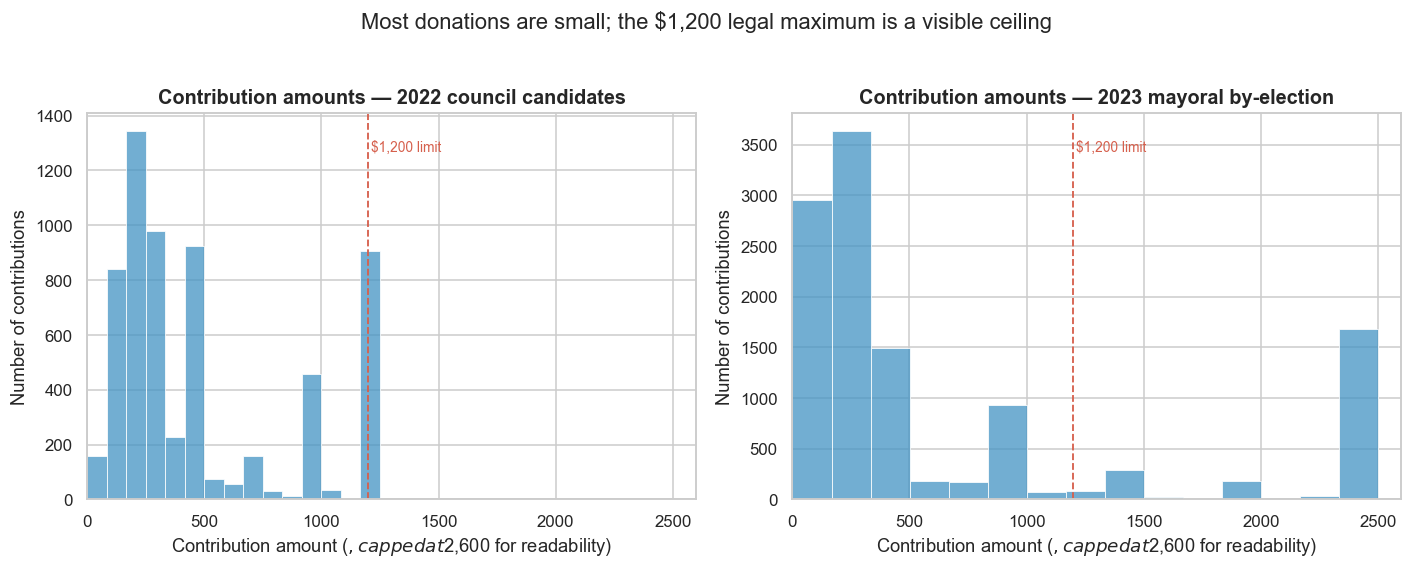

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, df, label in zip(axes, [council_2022, mayor_2023], ["2022 council candidates", "2023 mayoral by-election"]):
    sns.histplot(df.loc[~df["is_self_funded"], "amount"], bins=60, ax=ax, color=OTHER_CANDIDATE_COLOR)
    ax.set_xlim(0, 2600)
    ax.axvline(1200, color=REPEAT_HIGHLIGHT_COLOR, linestyle="--", linewidth=1.2)
    ax.text(1210, ax.get_ylim()[1] * 0.9, "$1,200 limit", color=REPEAT_HIGHLIGHT_COLOR, fontsize=9)
    ax.set_title(f"Contribution amounts — {label}")
    ax.set_xlabel("Contribution amount ($, capped at $2,600 for readability)")
    ax.set_ylabel("Number of contributions")
fig.suptitle("Most donations are small; the $1,200 legal maximum is a visible ceiling", y=1.03)
plt.tight_layout()
plt.show()

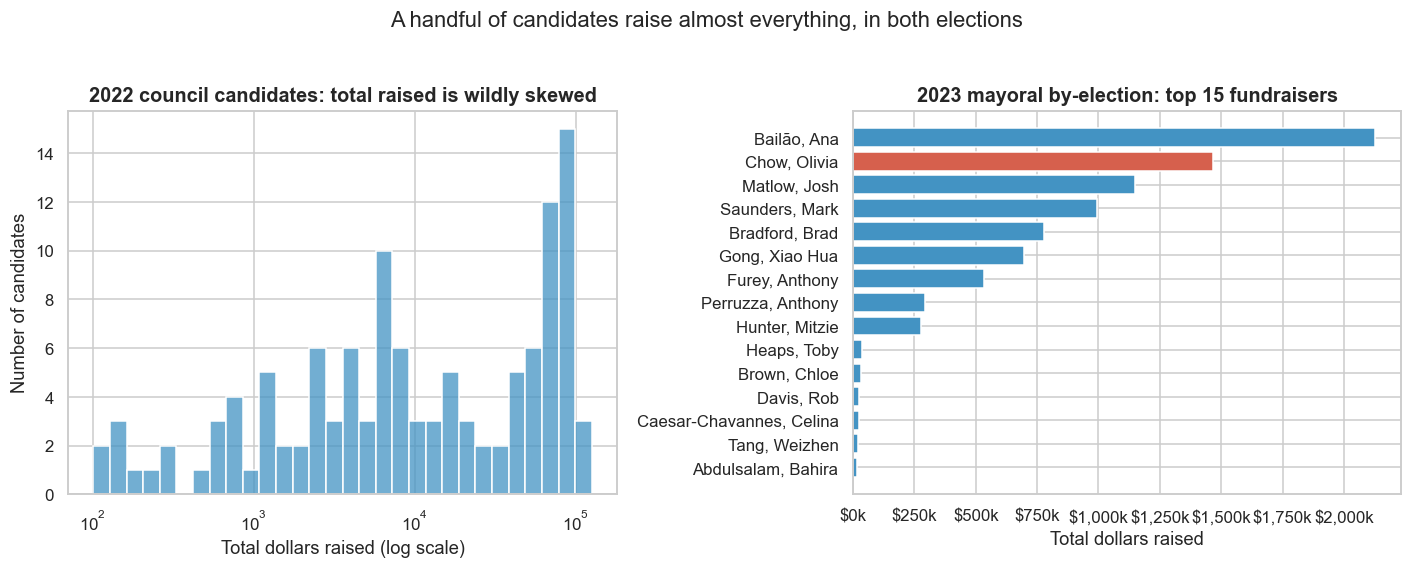

2022 council: top 10 candidates (28%) of $3,534,607 total raised by all 120 candidates
2023 mayor: top 3 candidates (55%) of $8,545,343 total raised by all 43 candidates


In [8]:
council_totals_quick = council_2022.groupby("candidate_raw")["amount"].sum().sort_values(ascending=False)
mayor_totals_quick = mayor_2023.groupby("candidate_raw")["amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(council_totals_quick, bins=30, log_scale=True, ax=axes[0], color=OTHER_CANDIDATE_COLOR)
axes[0].set_title("2022 council candidates: total raised is wildly skewed")
axes[0].set_xlabel("Total dollars raised (log scale)")
axes[0].set_ylabel("Number of candidates")

top15_mayor = mayor_totals_quick.head(15)
colors = [REPEAT_HIGHLIGHT_COLOR if normalize_name(c) in _norm_mayor_repeat else OTHER_CANDIDATE_COLOR
          for c in top15_mayor.index]
axes[1].barh(top15_mayor.index[::-1], top15_mayor.values[::-1], color=colors[::-1])
axes[1].set_title("2023 mayoral by-election: top 15 fundraisers")
axes[1].set_xlabel("Total dollars raised")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))

fig.suptitle("A handful of candidates raise almost everything, in both elections", y=1.03)
plt.tight_layout()
plt.show()

council_top10_share = council_totals_quick.head(10).sum() / council_totals_quick.sum()
mayor_top3_share = mayor_totals_quick.head(3).sum() / mayor_totals_quick.sum()
print(f"2022 council: top 10 candidates ({council_top10_share:.0%}) "
      f"of ${council_totals_quick.sum():,.0f} total raised by all 120 candidates")
print(f"2023 mayor: top 3 candidates ({mayor_top3_share:.0%}) "
      f"of ${mayor_totals_quick.sum():,.0f} total raised by all 43 candidates")

### Data-story potential — Part 1

The data is clean enough to work with directly (no missing postal codes/dates/amounts, sensible
formats) and the raw shape already surfaces two things worth carrying forward:

- **The $1,200 individual contribution limit is visible in the histogram itself** — a clean,
  intuitive detail for a reader ("here's the legal ceiling, and here's how many donors hit it").
- **Fundraising is heavily concentrated among a small number of candidates** in both elections —
  worth quantifying properly in Part 2 rather than resting on this quick look.

Nothing here is a story on its own yet; both points are set-up for what follows.


## Part 2 — Candidate-level fundraising profiles

For every candidate we build: total dollars raised, number of contributions, number of unique
donors (excluding self-funding), median/mean contribution, the share of donor dollars from the
top 10 and top 25 donors, a donor-concentration Gini coefficient, and the contribution-size-bin
mix. All 120 council candidates and all 43 mayoral candidates are preserved in the underlying
profile tables — graphics below focus on the candidates with enough activity to be worth reading.


In [9]:
def gini_coefficient(values):
    """Gini coefficient of an array of non-negative amounts (0 = perfectly equal)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n < 2 or x.sum() == 0:
        return np.nan
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def top_n_share(donor_totals, n):
    if len(donor_totals) == 0 or donor_totals.sum() == 0:
        return np.nan
    return donor_totals.sort_values(ascending=False).head(n).sum() / donor_totals.sum()


def build_candidate_profiles(df, group_cols=("candidate_raw",)):
    """One row per candidate: fundraising totals, donor-level stats, and concentration measures."""
    group_cols = list(group_cols)
    groups = df.groupby(group_cols)
    rows = []
    for keys, g in tqdm(groups, total=groups.ngroups, desc="Building candidate profiles"):
        keys = keys if isinstance(keys, tuple) else (keys,)
        donors = g.loc[~g["is_self_funded"]]
        donor_totals = donors.groupby("donor_id")["amount"].sum()
        bin_dollar_share = (
            donors.groupby("contribution_size_bin", observed=True)["amount"].sum() / donors["amount"].sum()
        )
        row = dict(zip(group_cols, keys))
        row.update({
            "total_amount": g["amount"].sum(),
            "n_contributions": len(g),
            "n_contributions_donor": len(donors),
            "n_self_funding_rows": int(g["is_self_funded"].sum()),
            "self_funding_amount": g.loc[g["is_self_funded"], "amount"].sum(),
            "n_unique_donors": donor_totals.shape[0],
            "median_contribution": donors["amount"].median(),
            "mean_contribution": donors["amount"].mean(),
            "q25_contribution": donors["amount"].quantile(0.25),
            "q75_contribution": donors["amount"].quantile(0.75),
            "gini_donor_totals": gini_coefficient(donor_totals.values),
            "first_contribution_date": g["date_received"].min(),
            "last_contribution_date": g["date_received"].max(),
        })
        for n in TOP_DONOR_CUTOFFS:
            row[f"top{n}_donor_share"] = top_n_share(donor_totals, n)
        for label in CONTRIBUTION_SIZE_LABELS:
            row[f"share_{label}"] = bin_dollar_share.get(label, 0.0)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("total_amount", ascending=False).reset_index(drop=True)


council_profiles = build_candidate_profiles(council_2022)
council_profiles = council_profiles.merge(
    council_2022[["candidate_raw", "ward", "repeat_candidate_group", "is_2026_repeat_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)

mayor_profiles = build_candidate_profiles(mayor_2023)
mayor_profiles = mayor_profiles.merge(
    mayor_2023[["candidate_raw", "repeat_candidate_group", "is_2026_repeat_candidate", "is_major_2023_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)

print(f"council_profiles: {len(council_profiles)} candidates")
print(f"mayor_profiles:   {len(mayor_profiles)} candidates")
council_profiles.head(10)[
    ["candidate_raw", "ward", "total_amount", "n_unique_donors", "median_contribution",
     "top10_donor_share", "gini_donor_totals", "repeat_candidate_group"]
]


Building candidate profiles:   0%|          | 0/120 [00:00<?, ?it/s]

Building candidate profiles:   0%|          | 0/43 [00:00<?, ?it/s]

council_profiles: 120 candidates
mayor_profiles:   43 candidates


,candidate_raw,ward,total_amount,n_unique_donors,median_contribution,top10_donor_share,gini_donor_totals,repeat_candidate_group
0,"Grimes, Mark",3,"126,049.37",127,"1,000.00",0.10,0.14,Not a known 2026 repeat candidate
1,"Burnside, Jon",16,"106,398.74",112,750.00,0.21,0.33,Not a known 2026 repeat candidate
2,"Bradford, Brad",19,"102,166.00",153,500.00,0.12,0.30,2026 council repeat (priority)
3,"Fletcher, Paula",14,"96,627.00",194,250.00,0.15,0.33,Not a known 2026 repeat candidate
4,"Lai, Cynthia",23,"95,720.00",207,300.00,0.13,0.38,Not a known 2026 repeat candidate
5,"Nunziata, Frances",5,"95,050.00",110,"1,000.00",0.18,0.26,2026 council repeat (other)
6,"Malik, Ausma",10,"94,070.46",261,200.00,0.13,0.43,2026 council repeat (other)
7,"Moise, Chris",13,"88,209.80",142,500.00,0.14,0.38,2026 council repeat (other)
8,"Pasternak, James",6,"87,322.00",100,"1,200.00",0.14,0.24,Not a known 2026 repeat candidate
9,"O'Brien Fehr, Markus",18,"87,112.54",197,300.00,0.14,0.32,Not a known 2026 repeat candidate


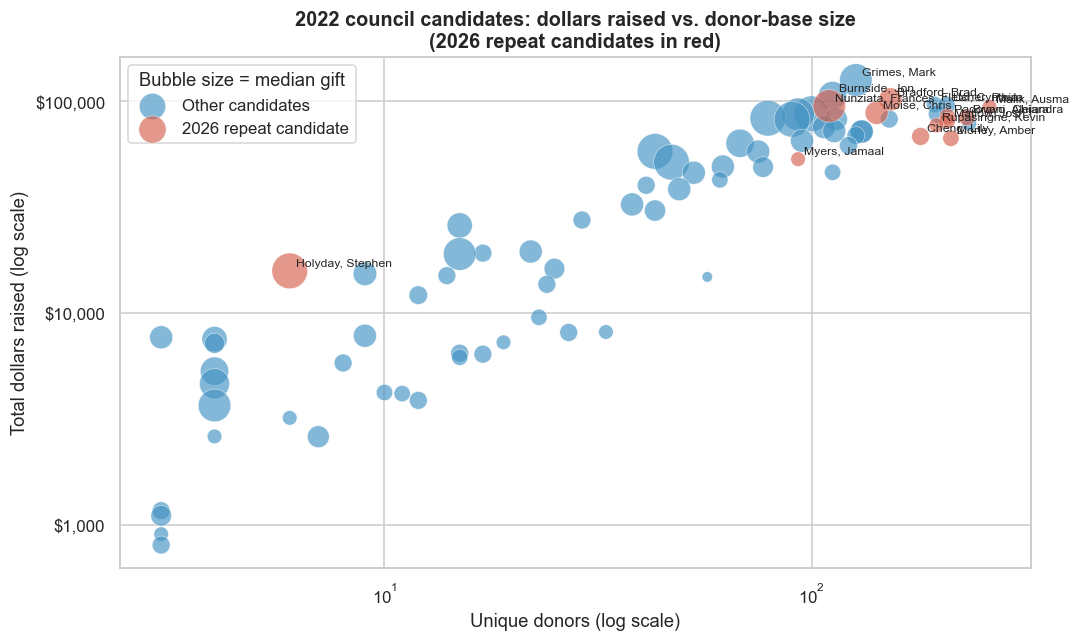

In [10]:
# Total $ raised vs. unique donors, with bubble size = median contribution — three fundraising
# dimensions in one chart. Above the diagonal-ish trend = fewer, bigger gifts; below = broader,
# smaller-dollar donor bases.
def plot_dollars_vs_donors(profiles, title, label_top_n=6, min_donors=3):
    plot_df = profiles.loc[profiles["n_unique_donors"] >= min_donors].copy()
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    is_repeat = plot_df["is_2026_repeat_candidate"].fillna(False)
    for mask, color, label in [(~is_repeat, OTHER_CANDIDATE_COLOR, "Other candidates"),
                                (is_repeat, REPEAT_HIGHLIGHT_COLOR, "2026 repeat candidate")]:
        sub = plot_df.loc[mask]
        ax.scatter(sub["n_unique_donors"], sub["total_amount"],
                   s=sub["median_contribution"].clip(upper=1200) / 2.2, alpha=0.65,
                   color=color, edgecolor="white", linewidth=0.4, label=label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Unique donors (log scale)")
    ax.set_ylabel("Total dollars raised (log scale)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_title(title)
    ax.legend(loc="upper left", frameon=True, title="Bubble size = median gift")

    label_set = pd.concat([
        plot_df.loc[is_repeat],
        plot_df.nlargest(label_top_n, "total_amount"),
    ]).drop_duplicates("candidate_raw")
    for _, r in label_set.iterrows():
        ax.annotate(r["candidate_raw"], (r["n_unique_donors"], r["total_amount"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")
    plt.tight_layout()
    plt.show()


plot_dollars_vs_donors(
    council_profiles,
    "2022 council candidates: dollars raised vs. donor-base size\n(2026 repeat candidates in red)",
)

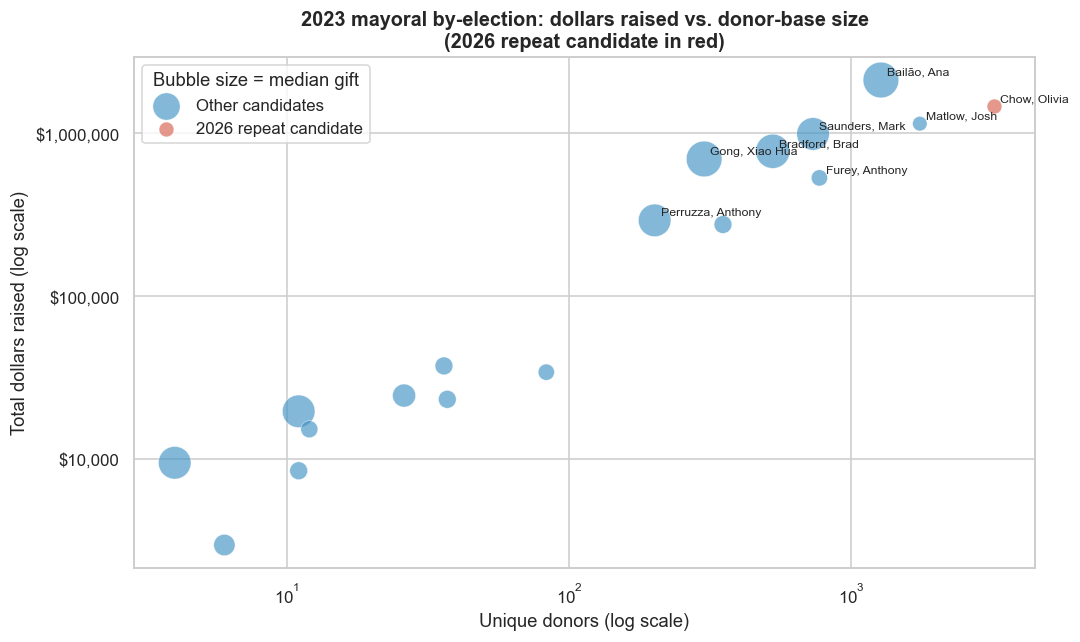

In [11]:
plot_dollars_vs_donors(
    mayor_profiles, "2023 mayoral by-election: dollars raised vs. donor-base size\n(2026 repeat candidate in red)",
    label_top_n=8, min_donors=3,
)

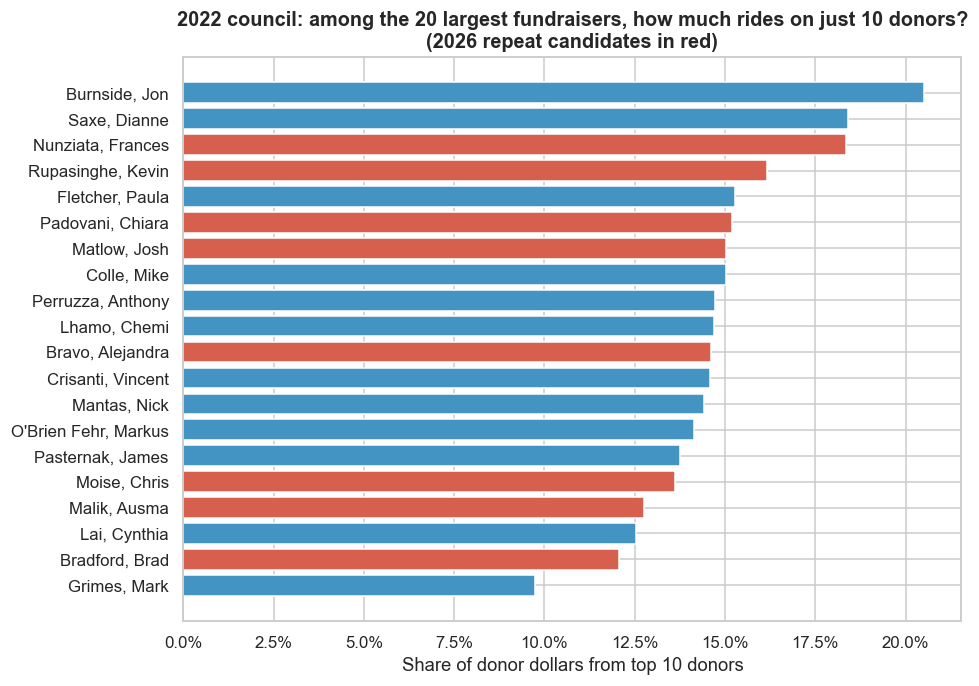

In [12]:
# Donor concentration: share of donor dollars from just the top 10 donors, for candidates with
# enough donors that the ratio is meaningful, restricted to the more substantial fundraisers so
# the chart stays readable.
def plot_top_donor_concentration(profiles, title, min_donors, top_n_candidates=20):
    plot_df = profiles.loc[profiles["n_unique_donors"] >= min_donors].nlargest(top_n_candidates, "total_amount")
    plot_df = plot_df.sort_values("top10_donor_share")
    colors = [REPEAT_HIGHLIGHT_COLOR if r else OTHER_CANDIDATE_COLOR for r in plot_df["is_2026_repeat_candidate"].fillna(False)]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(plot_df))))
    ax.barh(plot_df["candidate_raw"], plot_df["top10_donor_share"], color=colors)
    ax.set_xlabel("Share of donor dollars from top 10 donors")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_top_donor_concentration(
    council_profiles,
    f"2022 council: among the {20} largest fundraisers, how much rides on just 10 donors?\n(2026 repeat candidates in red)",
    min_donors=MIN_DONORS_FOR_RATIO_ANALYSIS,
)

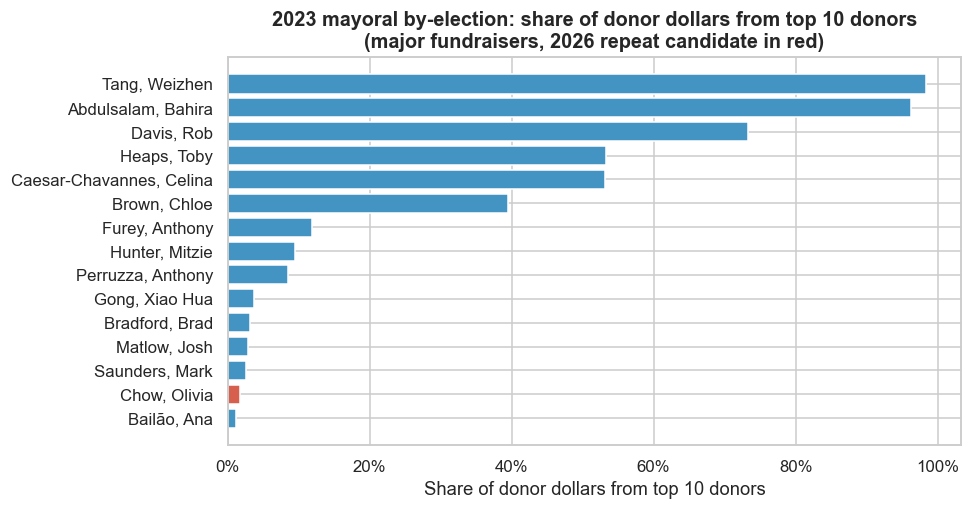

In [13]:
plot_top_donor_concentration(
    mayor_profiles,
    "2023 mayoral by-election: share of donor dollars from top 10 donors\n(major fundraisers, 2026 repeat candidate in red)",
    min_donors=MIN_DONORS_FOR_RATIO_ANALYSIS, top_n_candidates=15,
)

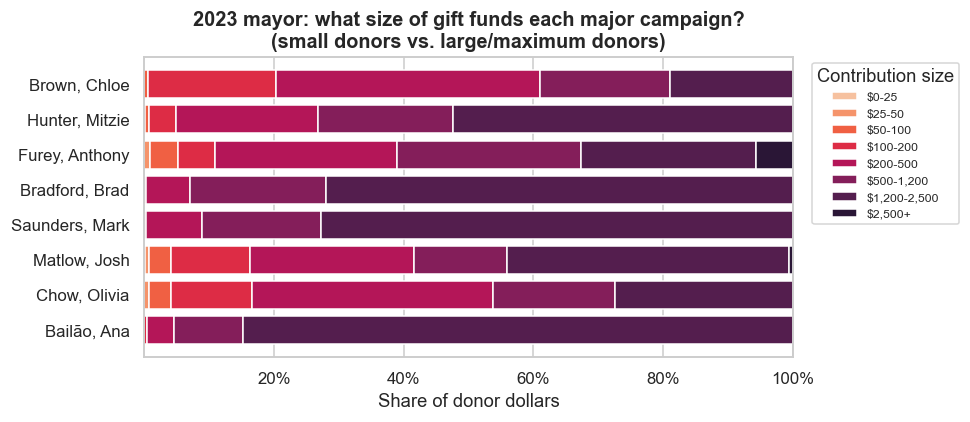

In [14]:
def plot_size_bin_mix(profiles, candidates, title):
    share_cols = [f"share_{label}" for label in CONTRIBUTION_SIZE_LABELS]
    plot_df = profiles.loc[profiles["candidate_raw"].isin(candidates)].set_index("candidate_raw")
    plot_df = plot_df.loc[candidates, share_cols].fillna(0)
    plot_df.columns = CONTRIBUTION_SIZE_LABELS

    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(plot_df))))
    left = np.zeros(len(plot_df))
    palette = sns.color_palette("rocket_r", len(CONTRIBUTION_SIZE_LABELS))
    for label, color in zip(CONTRIBUTION_SIZE_LABELS, palette):
        ax.barh(plot_df.index, plot_df[label], left=left, color=color, label=label)
        left += plot_df[label].values
    ax.set_xlabel("Share of donor dollars")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Contribution size")
    plt.tight_layout()
    plt.show()


mayor_order = mayor_profiles.loc[mayor_profiles["candidate_raw"].isin(MAJOR_2023_CANDIDATES)] \
    .sort_values("total_amount", ascending=False)["candidate_raw"].tolist()
plot_size_bin_mix(
    mayor_profiles, mayor_order,
    "2023 mayor: what size of gift funds each major campaign?\n(small donors vs. large/maximum donors)",
)

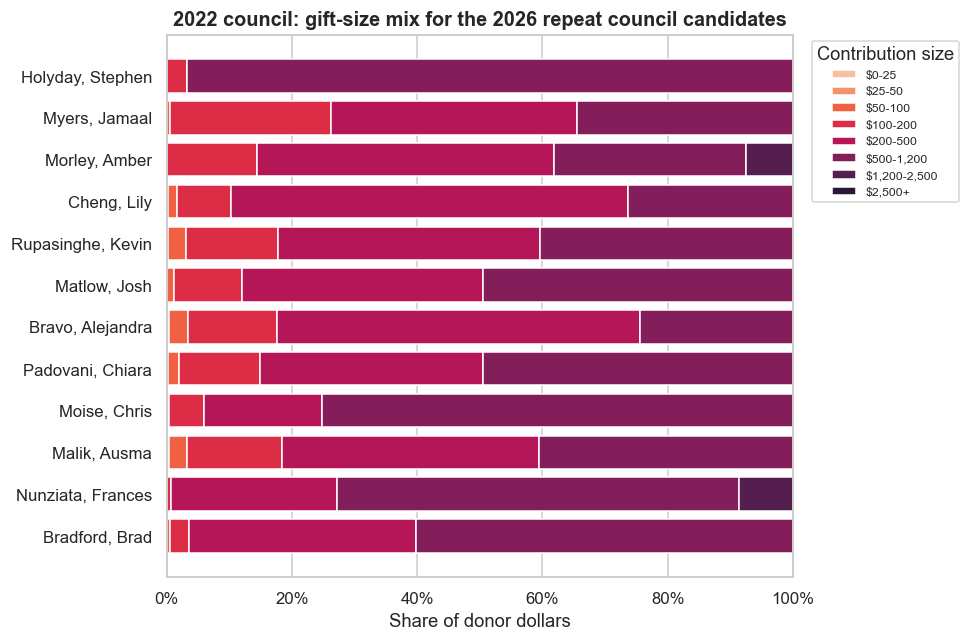

In [15]:
council_order = council_profiles.loc[council_profiles["candidate_raw"].isin(REPEAT_COUNCIL_CANDIDATES_2026)] \
    .sort_values("total_amount", ascending=False)["candidate_raw"].tolist()
plot_size_bin_mix(
    council_profiles, council_order,
    "2022 council: gift-size mix for the 2026 repeat council candidates",
)

### Data-story potential — Part 2

- **Fundraising is dominated by a small number of candidates in both races.** In 2022, the top 10
  of 120 council candidates raised roughly a third of all council dollars; in 2023, the top 3 of
  43 mayoral candidates raised the large majority of all mayoral dollars. This is intuitive,
  plausible, and easy to chart, but it's a fairly expected pattern for any candidate election —
  **moderate** story value on its own.
- **Donor-base size varies far more than money raised** for candidates who raise similar totals —
  the dollars-vs-donors scatter shows candidates reaching similar totals through very different
  numbers of donors (some through many small gifts, others through fewer, larger ones). This is a
  genuinely interesting contrast and sets up Part 8's repeat-candidate comparison nicely.
- **Stephen Holyday's 2022 campaign stands out immediately**: only 11 contribution rows total,
  and most of those are the candidate himself, his spouse, and other Holydays — a strikingly
  different fundraising model from the other 2026 repeat candidates, several of whom (Bravo,
  Malik, Rupasinghe, Padovani) built 200+ unique-donor bases. **This is a strong, concrete
  building block for Part 8.**
- The gift-size mix charts show real variation in what a "typical" contribution looks like across
  major 2023 candidates — worth watching in Part 5 to see whether it lines up with neighbourhood
  income.


## Part 3 — Geography of donations

**What already exists in the repository, and what doesn't.** Before building anything, we looked
for an existing postal-code-to-geography crosswalk or geocoding script. None exists: no
postal-code-to-CT table, no postal-code-to-FSA boundary file, and no code that assigns postal
codes to any geography anywhere in the repo. What the project *does* already have, and what we
reuse directly, are the destination geographies themselves:

- `src/data/wards.geo.json` — the 25 council ward boundaries.
- `data/toronto_election_turnout/census/processed/ct/statcan_2021_toronto_ct.geojson` — 622
  Toronto census-tract boundaries, from this project's own turnout-modelling work.

**How we bridge postal codes to those geographies.** A Canadian postal code's first three
characters (the Forward Sortation Area, or FSA) are a real, coarser geography — Toronto FSAs all
start with `M`. We don't have (and Statistics Canada's precise postal-code conversion file is
licensed, not something already sitting in this repo) a point location for every 6-character
postal code, so we geocode each **FSA** to its approximate centroid using `pgeocode`'s free
Canadian postal-code table, then spatially join that centroid to whichever ward/census-tract
polygon contains it.

**This is an approximation, and it matters where it matters:** every donor sharing an FSA is
assigned to the same ward and census tract, even though real FSAs are not identical to CT or ward
boundaries. Downtown FSAs are small and this is a good approximation; a few suburban FSAs are
large enough to span more than one ward or CT, which would blur a genuinely borderline case. We
flag this again wherever the precision of a specific finding depends on it.


In [16]:
# Geocode every FSA seen in either election to an approximate centroid, once.
all_fsas = sorted(set(council_2022["fsa"]) | set(mayor_2023["fsa"]))
nomi = pgeocode.Nominatim(PGEOCODE_COUNTRY)
fsa_lookup = nomi.query_postal_code(all_fsas)[["postal_code", "latitude", "longitude", "place_name"]]
fsa_lookup = fsa_lookup.rename(columns={"postal_code": "fsa"}).set_index("fsa")

n_missing = fsa_lookup["latitude"].isna().sum()
print(f"{len(all_fsas)} unique FSAs across both elections; {n_missing} could not be geocoded:")
print(fsa_lookup.loc[fsa_lookup["latitude"].isna()].index.tolist())

404 unique FSAs across both elections; 5 could not be geocoded:
['L3G', 'L3L', 'M0M', 'M6Z', 'M8K']


In [17]:
wards_gdf = gpd.read_file(WARDS_GEOJSON)[["num", "name", "geometry"]].rename(
    columns={"num": "contributor_ward", "name": "contributor_ward_name"}
)
ct_gdf = gpd.read_file(CENSUS_CT_GEOJSON)[["CTUID", "geometry"]].rename(columns={"CTUID": "ctuid"})


def assign_donor_geography(df, fsa_lookup, wards_gdf, ct_gdf):
    """Attach FSA-centroid lat/lon, containing ward, and containing census tract to each row."""
    out = df.merge(fsa_lookup[["latitude", "longitude"]], left_on="fsa", right_index=True, how="left")
    has_point = out["latitude"].notna()
    points = gpd.GeoDataFrame(
        out.loc[has_point],
        geometry=gpd.points_from_xy(out.loc[has_point, "longitude"], out.loc[has_point, "latitude"]),
        crs="EPSG:4326",
    )
    points = gpd.sjoin(points, wards_gdf, how="left", predicate="within").drop(columns="index_right")
    points = gpd.sjoin(points, ct_gdf, how="left", predicate="within").drop(columns="index_right")
    out = out.merge(
        points[["contributor_ward", "contributor_ward_name", "ctuid"]],
        left_index=True, right_index=True, how="left",
    )
    return out


council_2022 = assign_donor_geography(council_2022, fsa_lookup, wards_gdf, ct_gdf)
mayor_2023 = assign_donor_geography(mayor_2023, fsa_lookup, wards_gdf, ct_gdf)

for label, df in [("council_2022", council_2022), ("mayor_2023", mayor_2023)]:
    toronto = df.loc[df["is_toronto_postal"]]
    print(f"{label}: {len(df)} rows, {df['latitude'].isna().sum()} not geocoded, "
          f"{toronto['ctuid'].isna().sum()} Toronto rows not matched to a census tract")

council_2022: 6467 rows, 10 not geocoded, 7 Toronto rows not matched to a census tract
mayor_2023: 11815 rows, 4 not geocoded, 1 Toronto rows not matched to a census tract


In [18]:
def normalize_ctuid(x):
    """Consistent 'XXXXXXX.XX' string key so CTUID/ctuid/ctuid2021/GEO_NAME all join cleanly."""
    if pd.isna(x):
        return None
    return f"{float(x):.2f}"


census_master = pd.read_csv(CENSUS_CT_MASTER_CSV)
census_master["ctuid_norm"] = census_master["ctuid"].apply(normalize_ctuid)

# Supplement with the two income/shelter-cost variables the curated master table omits, pulled
# from the file named in the brief (toronto-ct-small.csv), pivoted from its long StatCan format.
census_small = pd.read_csv(CENSUS_CT_SMALL_CSV)
census_small["ctuid_norm"] = census_small["GEO_NAME"].apply(normalize_ctuid)
income_codes = ["income_total_median", "housing_shelter_total", "housing_shelter_30plus"]
income_wide = census_small.loc[census_small["CHARACTERISTIC_CODE"].isin(income_codes)].pivot(
    index="ctuid_norm", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL"
)
income_wide["shelter_cost_30plus_share"] = income_wide["housing_shelter_30plus"] / income_wide["housing_shelter_total"]
income_wide = income_wide.rename(columns={"income_total_median": "median_individual_income"})

census_master = census_master.merge(
    income_wide[["median_individual_income", "shelter_cost_30plus_share"]], on="ctuid_norm", how="left"
)

ct_gdf["ctuid_norm"] = ct_gdf["ctuid"].apply(normalize_ctuid)
ct_geo = ct_gdf.merge(census_master, on="ctuid_norm", how="left", suffixes=("", "_census"))

print(f"census_master: {len(census_master)} {CENSUS_YEAR} census tracts, "
      f"{census_master['population_total'].isna().sum()} missing population")
print(f"ct_geo (geometry + census, ready for mapping): {len(ct_geo)} tracts")
ct_geo[["ctuid_norm", "population_total", "population_density_per_km2", "median_individual_income"]].describe()


census_master: 622 2021 census tracts, 0 missing population
ct_geo (geometry + census, ready for mapping): 622 tracts


,population_total,population_density_per_km2,median_individual_income
count,622.00,622.00,620.00
mean,"4,795.11","8,106.88","42,056.13"
std,"1,948.81","9,032.98","11,816.26"
min,119.00,40.70,"23,800.00"
25%,"3,475.25","3,220.20","33,200.00"
50%,"4,676.50","5,572.10","38,400.00"
75%,"5,919.25","8,948.90","48,400.00"
max,"13,554.00","77,545.30","87,000.00"


In [19]:
def aggregate_to_ct(df, candidate_col=None, candidate_value=None):
    """CT-level totals for Toronto rows, optionally restricted to one candidate."""
    sub = df.loc[df["is_toronto_postal"] & df["ctuid"].notna()]
    if candidate_col is not None:
        sub = sub.loc[sub[candidate_col] == candidate_value]
    donors = sub.loc[~sub["is_self_funded"]]
    agg = sub.groupby("ctuid").agg(total_amount=("amount", "sum"), n_contributions=("amount", "size"))
    agg["n_unique_donors"] = donors.groupby("ctuid")["donor_id"].nunique()
    agg["n_unique_donors"] = agg["n_unique_donors"].fillna(0).astype(int)
    return agg.reset_index()


def with_per_capita(ct_agg, ct_geo):
    out = ct_geo[["ctuid_norm", "population_total", "geometry"]].merge(
        ct_agg.rename(columns={"ctuid": "ctuid_norm"}), on="ctuid_norm", how="left"
    )
    for col in ["total_amount", "n_contributions", "n_unique_donors"]:
        out[col] = out[col].fillna(0)
    out["donors_per_1000"] = 1000 * out["n_unique_donors"] / out["population_total"]
    out["dollars_per_capita"] = out["total_amount"] / out["population_total"]
    return out


council_ct_agg = with_per_capita(aggregate_to_ct(council_2022), ct_geo)
mayor_ct_agg = with_per_capita(aggregate_to_ct(mayor_2023), ct_geo)

n_ct_with_council_donor = (council_ct_agg["n_unique_donors"] > 0).sum()
n_ct_with_mayor_donor = (mayor_ct_agg["n_unique_donors"] > 0).sum()
print(f"Council 2022: {n_ct_with_council_donor}/{len(council_ct_agg)} Toronto census tracts "
      f"({n_ct_with_council_donor/len(council_ct_agg):.0%}) contain at least one donor")
print(f"Mayor 2023:   {n_ct_with_mayor_donor}/{len(mayor_ct_agg)} Toronto census tracts "
      f"({n_ct_with_mayor_donor/len(mayor_ct_agg):.0%}) contain at least one donor")
mayor_ct_agg[["ctuid_norm", "population_total", "total_amount", "n_unique_donors", "donors_per_1000", "dollars_per_capita"]].describe()

Council 2022: 96/622 Toronto census tracts (15%) contain at least one donor
Mayor 2023:   96/622 Toronto census tracts (15%) contain at least one donor


,population_total,total_amount,n_unique_donors,donors_per_1000,dollars_per_capita
count,622.00,622.00,622.00,622.00,622.00
mean,"4,795.11","10,230.12",11.72,3.52,2.97
std,"1,948.81","35,267.29",39.55,15.52,12.68
min,119.00,0.00,0.00,0.00,0.00
25%,"3,475.25",0.00,0.00,0.00,0.00
50%,"4,676.50",0.00,0.00,0.00,0.00
75%,"5,919.25",0.00,0.00,0.00,0.00
max,"13,554.00","313,993.24",324.00,190.32,157.08


**Important resolution caveat before reading that "15%" number as a fact about donor geography.**
Only about 100 distinct Toronto FSAs appear in either dataset — Toronto has roughly that many
FSAs in total — and our geocoding method sends every donor from the same FSA to the *same* single
census tract (whichever one contains that FSA's centroid). That mechanically caps the number of
census tracts that can ever register a donor at roughly 100 of 622 (~16%), regardless of how
widely donations are actually spread across the city. **The 15% figure above is an artifact of
FSA-level resolution, not evidence that donations come from only 15% of Toronto neighbourhoods.**

The question the data *can* actually answer at FSA resolution is: what share of Toronto's ~100
postal areas contain at least one donor, and how concentrated are the dollars across them? We
answer that properly below, and reserve the census-tract maps for the per-capita measures (which
remain valid CT-by-CT, using each CT's real population) while flagging that neighbouring tracts
sharing one FSA will show identical values rather than genuine block-by-block variation.


In [20]:
def fsa_concentration(df):
    tor = df.loc[df["is_toronto_postal"]]
    fsa_totals = tor.groupby("fsa")["amount"].sum().sort_values(ascending=False)
    n_toronto_fsas = fsa_totals.shape[0]
    return pd.Series({
        "toronto_fsas_with_any_$": n_toronto_fsas,
        "top10_fsa_$_share": fsa_totals.head(10).sum() / fsa_totals.sum(),
        "top25_fsa_$_share": fsa_totals.head(25).sum() / fsa_totals.sum(),
    }), fsa_totals


council_fsa_stats, council_fsa_totals = fsa_concentration(council_2022)
mayor_fsa_stats, mayor_fsa_totals = fsa_concentration(mayor_2023)

n_toronto_fsas_total = pd.Series(all_fsas).loc[pd.Series(all_fsas).str.startswith("M")].nunique()
print(f"Toronto FSAs appearing in either dataset: {n_toronto_fsas_total}")
print("\n2022 council, by postal area (FSA):")
print(council_fsa_stats)
print("\n2023 mayor, by postal area (FSA):")
print(mayor_fsa_stats)

Toronto FSAs appearing in either dataset: 102

2022 council, by postal area (FSA):
toronto_fsas_with_any_$   100.00
top10_fsa_$_share           0.27
top25_fsa_$_share           0.52
dtype: float64

2023 mayor, by postal area (FSA):
toronto_fsas_with_any_$   100.00
top10_fsa_$_share           0.35
top25_fsa_$_share           0.59
dtype: float64


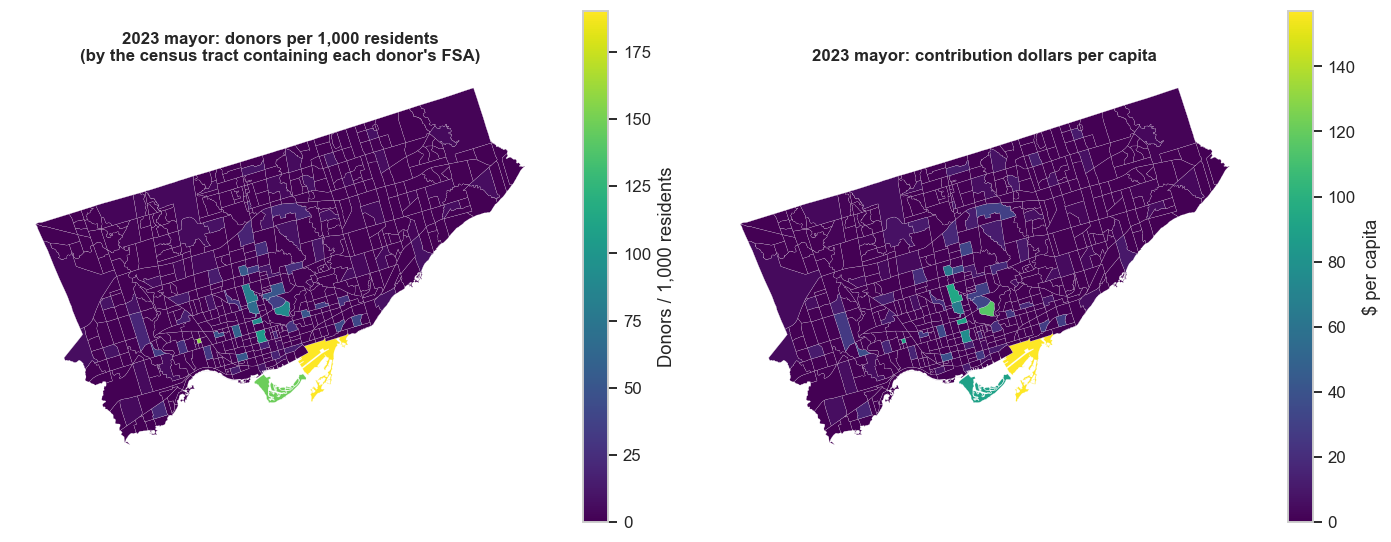

In [21]:
def plot_ct_choropleth(ct_agg_gdf, column, title, legend_label, ax=None, cmap=TORONTO_MAP_CMAP):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
    plot_df = gpd.GeoDataFrame(ct_agg_gdf, geometry="geometry", crs="EPSG:4326")
    plot_df.plot(column=column, cmap=cmap, linewidth=0.1, edgecolor="white", ax=ax, legend=True,
                 legend_kwds={"label": legend_label, "shrink": 0.7})
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    if own_fig:
        plt.tight_layout()
        plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 7))
plot_ct_choropleth(mayor_ct_agg, "donors_per_1000",
                   "2023 mayor: donors per 1,000 residents\n(by the census tract containing each donor's FSA)",
                   "Donors / 1,000 residents", ax=axes[0])
plot_ct_choropleth(mayor_ct_agg, "dollars_per_capita",
                   "2023 mayor: contribution dollars per capita",
                   "$ per capita", ax=axes[1])
plt.tight_layout()
plt.show()

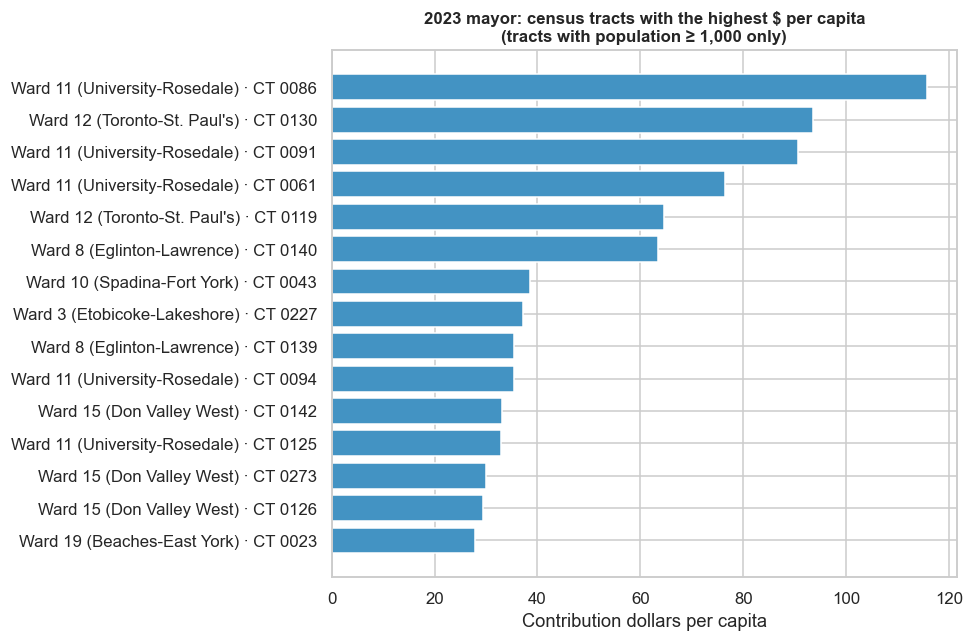

In [22]:
# Label each census tract with its containing ward, for readable axis labels on ranked charts
# (a bare CTUID means nothing to a reader; "Ward 12 (Toronto-St. Paul's)" does).
ct_centroids = ct_geo.copy()
ct_centroids["geometry"] = ct_centroids.representative_point()
ct_ward_labels = gpd.sjoin(ct_centroids[["ctuid_norm", "geometry"]], wards_gdf, how="left", predicate="within")
ct_geo = ct_geo.merge(
    ct_ward_labels[["ctuid_norm", "contributor_ward", "contributor_ward_name"]], on="ctuid_norm", how="left"
)
council_ct_agg = council_ct_agg.merge(
    ct_geo[["ctuid_norm", "contributor_ward", "contributor_ward_name"]], on="ctuid_norm", how="left"
)
mayor_ct_agg = mayor_ct_agg.merge(
    ct_geo[["ctuid_norm", "contributor_ward", "contributor_ward_name"]], on="ctuid_norm", how="left"
)


def plot_top_ct_ranking(ct_agg, column, title, xlabel, top_n=15):
    plot_df = ct_agg.loc[ct_agg["population_total"] >= MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING].nlargest(top_n, column)
    plot_df = plot_df.sort_values(column)
    # Each label includes the CT number so identical-ward tracts don't collapse onto one bar.
    labels = [f"Ward {int(w)} ({n}) · CT {ctid.split('.')[0][-4:]}" if pd.notna(w) else f"CT {ctid}"
              for w, n, ctid in zip(plot_df["contributor_ward"], plot_df["contributor_ward_name"], plot_df["ctuid_norm"])]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(len(plot_df)), plot_df[column], color=OTHER_CANDIDATE_COLOR)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_top_ct_ranking(
    mayor_ct_agg, "dollars_per_capita",
    f"2023 mayor: census tracts with the highest $ per capita\n(tracts with population ≥ {MIN_CT_POPULATION_FOR_PER_CAPITA_RANKING:,} only)",
    "Contribution dollars per capita",
)

### Candidate geography: does each campaign have its own financial constituency?

For the 8 major 2023 mayoral candidates, we compute (at the FSA level, the resolution the data
actually supports): how many of Toronto's ~100 postal areas contributed anything, and which five
postal areas gave the most money.


In [23]:
def candidate_fsa_profile(df, candidate_col, candidate_value, n_top=5):
    sub = df.loc[(df[candidate_col] == candidate_value) & df["is_toronto_postal"]]
    fsa_totals = sub.groupby("fsa")["amount"].sum().sort_values(ascending=False)
    top = fsa_totals.head(n_top)
    return pd.Series({
        "toronto_fsas_reached": fsa_totals.shape[0],
        "pct_of_toronto_fsas": fsa_totals.shape[0] / n_toronto_fsas_total,
        f"top{n_top}_fsa_$_share": top.sum() / fsa_totals.sum() if fsa_totals.sum() else np.nan,
        "gini_across_fsas": gini_coefficient(fsa_totals.values),
        "top_fsas": ", ".join(top.index),
    })


mayor_fsa_profiles = pd.DataFrame({
    cand: candidate_fsa_profile(mayor_2023, "candidate_raw", cand) for cand in MAJOR_2023_CANDIDATES
}).T
mayor_fsa_profiles

,toronto_fsas_reached,pct_of_toronto_fsas,top5_fsa_$_share,gini_across_fsas,top_fsas
"Chow, Olivia",98,0.96,0.23,0.58,"M6G, M5R, M6H, M4L, M4K"
"Bailão, Ana",92,0.90,0.26,0.56,"M4W, M5P, M5R, M4V, M4T"
"Saunders, Mark",82,0.80,0.32,0.61,"M9A, M4N, M4W, M5P, M5R"
"Furey, Anthony",86,0.84,0.30,0.56,"M5P, M4V, M4W, M4N, M5R"
"Matlow, Josh",90,0.88,0.42,0.69,"M4V, M5P, M4S, M5R, M5N"
"Hunter, Mitzie",83,0.81,0.26,0.56,"M5V, M4W, M1E, M4A, M5A"
"Bradford, Brad",80,0.78,0.29,0.54,"M4W, M4E, M5R, M4V, M4N"
"Brown, Chloe",47,0.46,0.41,0.53,"M6G, M6J, M5R, M5S, M5T"


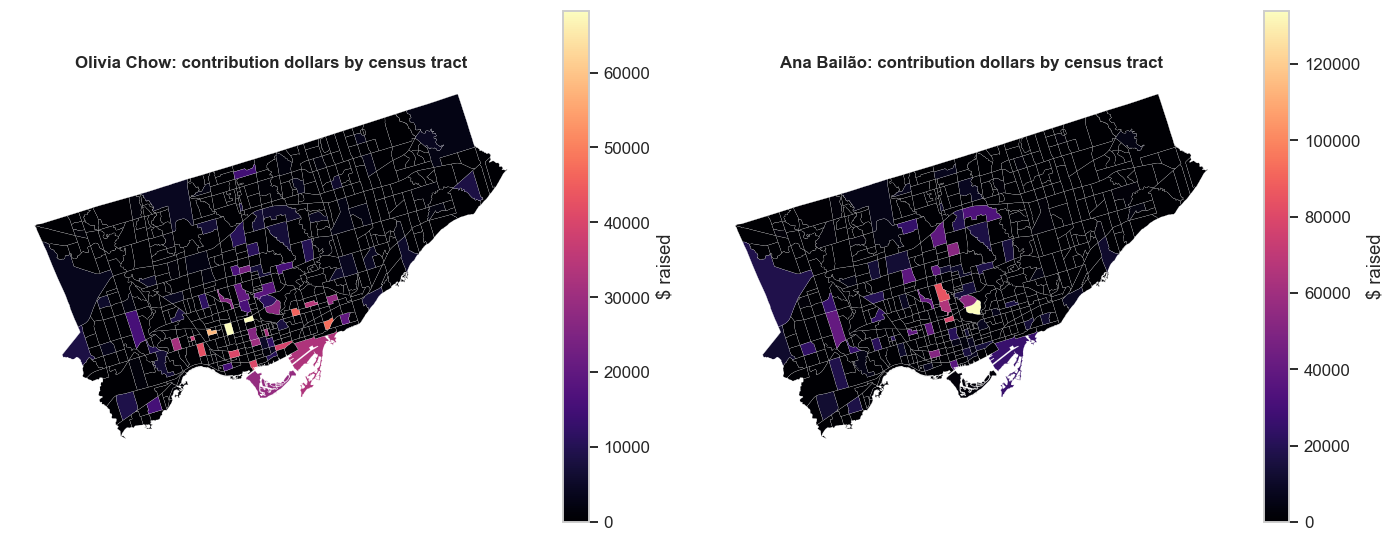

In [24]:
# Chow reaches 98 of ~100 Toronto postal areas (the most of any major candidate) and her top-5
# areas are a middling ~23% of her money. Bailão reaches slightly fewer (92) but her top-5 areas —
# Rosedale (M4W), Forest Hill (M5P), Yonge-Eglinton (M5R), Rosedale/Summerhill (M4V), Moore Park
# (M4T) — are all established, high-income enclaves, whereas two of Chow's top areas (M6G Christie/
# Regent Park-adjacent, M6H Bloorcourt) are more mixed, gentrifying west-end neighbourhoods. We map
# the two side by side as the clearest compositional contrast among the majors.
chow_ct = with_per_capita(aggregate_to_ct(mayor_2023, "candidate_raw", "Chow, Olivia"), ct_geo)
bailao_ct = with_per_capita(aggregate_to_ct(mayor_2023, "candidate_raw", "Bailão, Ana"), ct_geo)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
plot_ct_choropleth(chow_ct, "total_amount", "Olivia Chow: contribution dollars by census tract",
                    "$ raised", ax=axes[0], cmap="magma")
plot_ct_choropleth(bailao_ct, "total_amount", "Ana Bailão: contribution dollars by census tract",
                    "$ raised", ax=axes[1], cmap="magma")
plt.tight_layout()
plt.show()

### Data-story potential — Part 3

- **Political money is not evenly spread across Toronto, and the map makes that instantly
  legible.** Both the 2023 mayoral choropleths and the top-tract ranking point to the same small
  cluster of central, high-income neighbourhoods (Rosedale, Forest Hill, the Annex, Yonge-
  Eglinton) as the financial core of the city, regardless of which candidate is being funded.
  **Strong, visual, and intuitive** — this is the clearest map-based angle in the notebook so far.
- **Participation is broader than concentration.** Virtually every Toronto postal area (98-100%
  for the top candidates) contributes *something*; it's the dollar amounts, not the geographic
  reach, that concentrate hard in a handful of wealthy areas. That is a more precise and more
  interesting claim than "donations are geographically sparse" — and it's an important correction
  to make explicitly, since a naive read of the raw census-tract coverage number would say the
  opposite.
- **A genuine compositional difference between Chow and Bailão**, not just a difference in scale:
  Bailão's biggest-dollar areas are almost uniformly Toronto's wealthiest legacy neighbourhoods,
  while Chow's include more mixed, gentrifying west-end areas alongside some of the same wealthy
  enclaves. This is promising but should be treated as suggestive rather than definitive until
  Part 5 checks whether it holds up against real demographic variables rather than neighbourhood
  reputations.
- **Caveat that must travel with any of this:** everything here is FSA-resolution, not exact
  address-level geography. The choropleth maps in particular will show visibly identical values
  across neighbouring census tracts that happen to share one FSA — a real artifact of the method,
  not a finding about hyperlocal variation.


## Part 4 — Local versus non-local fundraising (council)

For 2022 council candidates, the contribution file already tells us each candidate's own ward
(the `ward` column, straight from the filing data — see Part 1). Combined with each donor's
FSA-derived ward from Part 3, we can classify every council contribution as coming from:

1. **the candidate's own ward**,
2. **elsewhere in Toronto**, or
3. **outside Toronto**.

This is the FSA-centroid approximation again: a donor is counted as "in-ward" only if their FSA's
centroid falls inside the candidate's ward polygon, so donors near a ward boundary can occasionally
be misclassified. We report both **donor-count shares** and **dollar shares**, since they can tell
different stories (a campaign can be dollar-dependent on a few big out-of-ward donors while still
being donor-majority local, or vice versa).


In [25]:
GEO_CATEGORY_OWN_WARD = "Own ward"
GEO_CATEGORY_ELSEWHERE_TORONTO = "Elsewhere Toronto"
GEO_CATEGORY_OUTSIDE_TORONTO = "Outside Toronto"
GEO_CATEGORY_UNKNOWN = "Unknown (not geocoded)"


def classify_geo_category(row):
    if pd.isna(row["latitude"]):
        return GEO_CATEGORY_UNKNOWN
    if not row["is_toronto_postal"]:
        return GEO_CATEGORY_OUTSIDE_TORONTO
    if pd.notna(row["contributor_ward"]) and int(row["contributor_ward"]) == int(row["ward"]):
        return GEO_CATEGORY_OWN_WARD
    return GEO_CATEGORY_ELSEWHERE_TORONTO


council_2022["geo_category"] = council_2022.apply(classify_geo_category, axis=1)
print(council_2022["geo_category"].value_counts(normalize=True).mul(100).round(1))


def local_fundraising_profile(df):
    rows = []
    for cand, g in df.groupby("candidate_raw"):
        donors = g.loc[~g["is_self_funded"]]
        dollar_share = g.groupby("geo_category")["amount"].sum() / g["amount"].sum()
        donor_share = donors.drop_duplicates("donor_id").groupby("geo_category").size() / donors["donor_id"].nunique()
        own_ward_donors = donors.loc[donors["geo_category"] == GEO_CATEGORY_OWN_WARD, "amount"]
        elsewhere_donors = donors.loc[donors["geo_category"] == GEO_CATEGORY_ELSEWHERE_TORONTO, "amount"]
        rows.append({
            "candidate_raw": cand,
            "ward": g["ward"].iloc[0],
            "n_unique_donors": donors["donor_id"].nunique(),
            "own_ward_dollar_share": dollar_share.get(GEO_CATEGORY_OWN_WARD, 0.0),
            "elsewhere_toronto_dollar_share": dollar_share.get(GEO_CATEGORY_ELSEWHERE_TORONTO, 0.0),
            "outside_toronto_dollar_share": dollar_share.get(GEO_CATEGORY_OUTSIDE_TORONTO, 0.0),
            "own_ward_donor_share": donor_share.get(GEO_CATEGORY_OWN_WARD, 0.0),
            "elsewhere_toronto_donor_share": donor_share.get(GEO_CATEGORY_ELSEWHERE_TORONTO, 0.0),
            "outside_toronto_donor_share": donor_share.get(GEO_CATEGORY_OUTSIDE_TORONTO, 0.0),
            "median_own_ward_contribution": own_ward_donors.median(),
            "median_elsewhere_toronto_contribution": elsewhere_donors.median(),
        })
    return pd.DataFrame(rows)


council_local_profiles = local_fundraising_profile(council_2022)
council_local_profiles = council_local_profiles.merge(
    council_2022[["candidate_raw", "repeat_candidate_group", "is_2026_repeat_candidate"]].drop_duplicates("candidate_raw"),
    on="candidate_raw", how="left",
)
council_local_profiles.sort_values("own_ward_dollar_share", ascending=False).head(10)[
    ["candidate_raw", "ward", "n_unique_donors", "own_ward_dollar_share", "own_ward_donor_share", "repeat_candidate_group"]
]


geo_category
Elsewhere Toronto        44.50
Own ward                 38.40
Outside Toronto          16.90
Unknown (not geocoded)    0.20
Name: proportion, dtype: float64


,candidate_raw,ward,n_unique_donors,own_ward_dollar_share,own_ward_donor_share,repeat_candidate_group
0,"Abbey, Abraham",1,0,1.00,0.00,Not a known 2026 repeat candidate
14,"Braniff, Donna",19,1,1.00,1.00,Not a known 2026 repeat candidate
12,"Beatty, Paul",21,0,1.00,0.00,Not a known 2026 repeat candidate
10,"Avila, Miguel",13,0,1.00,0.00,Not a known 2026 repeat candidate
53,"Khatchadourian, Serge",22,0,1.00,0.00,Not a known 2026 repeat candidate
36,"Fernando, Ashan",25,2,1.00,1.00,Not a known 2026 repeat candidate
28,"Daniel, Hansie",21,0,1.00,0.00,Not a known 2026 repeat candidate
30,"De Marco, John",14,0,1.00,0.00,Not a known 2026 repeat candidate
42,"Golding, Adam",11,0,1.00,0.00,Not a known 2026 repeat candidate
46,"Houghron, Mosea",9,0,1.00,0.00,Not a known 2026 repeat candidate


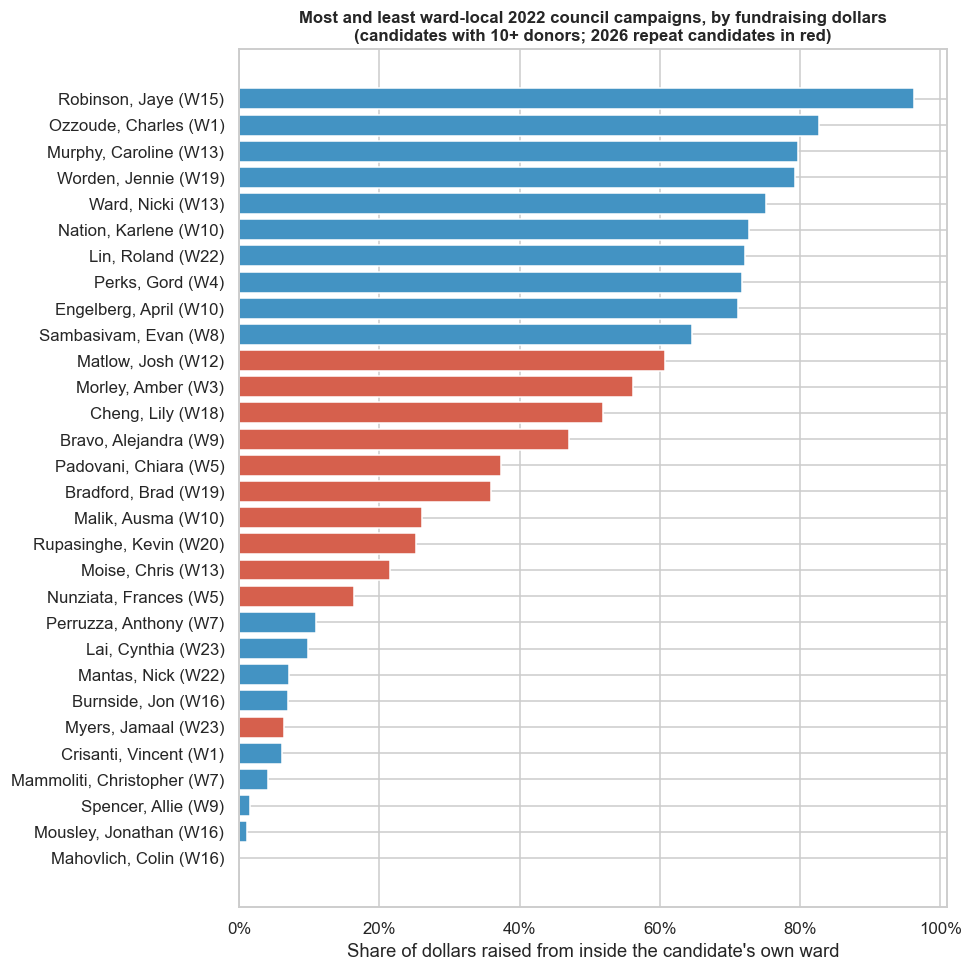

In [26]:
def plot_local_share_ranking(profiles, share_col, title, xlabel, min_donors=MIN_DONORS_FOR_RATIO_ANALYSIS,
                              n_extremes=10):
    """Rank candidates by a local-fundraising share; show the most-local and least-local
    extremes among candidates with enough donors to be meaningful, plus every 2026 repeat
    candidate regardless of where they fall."""
    qualified = profiles.loc[profiles["n_unique_donors"] >= min_donors]
    extremes = pd.concat([qualified.nlargest(n_extremes, share_col), qualified.nsmallest(n_extremes, share_col)])
    repeats = qualified.loc[qualified["is_2026_repeat_candidate"]]
    plot_df = pd.concat([extremes, repeats]).drop_duplicates("candidate_raw").sort_values(share_col)

    colors = [REPEAT_HIGHLIGHT_COLOR if r else OTHER_CANDIDATE_COLOR for r in plot_df["is_2026_repeat_candidate"]]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.3 * len(plot_df))))
    ax.barh(plot_df["candidate_raw"] + " (W" + plot_df["ward"].astype(int).astype(str) + ")", plot_df[share_col], color=colors)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()


plot_local_share_ranking(
    council_local_profiles, "own_ward_dollar_share",
    "Most and least ward-local 2022 council campaigns, by fundraising dollars\n(candidates with 10+ donors; 2026 repeat candidates in red)",
    "Share of dollars raised from inside the candidate's own ward",
)


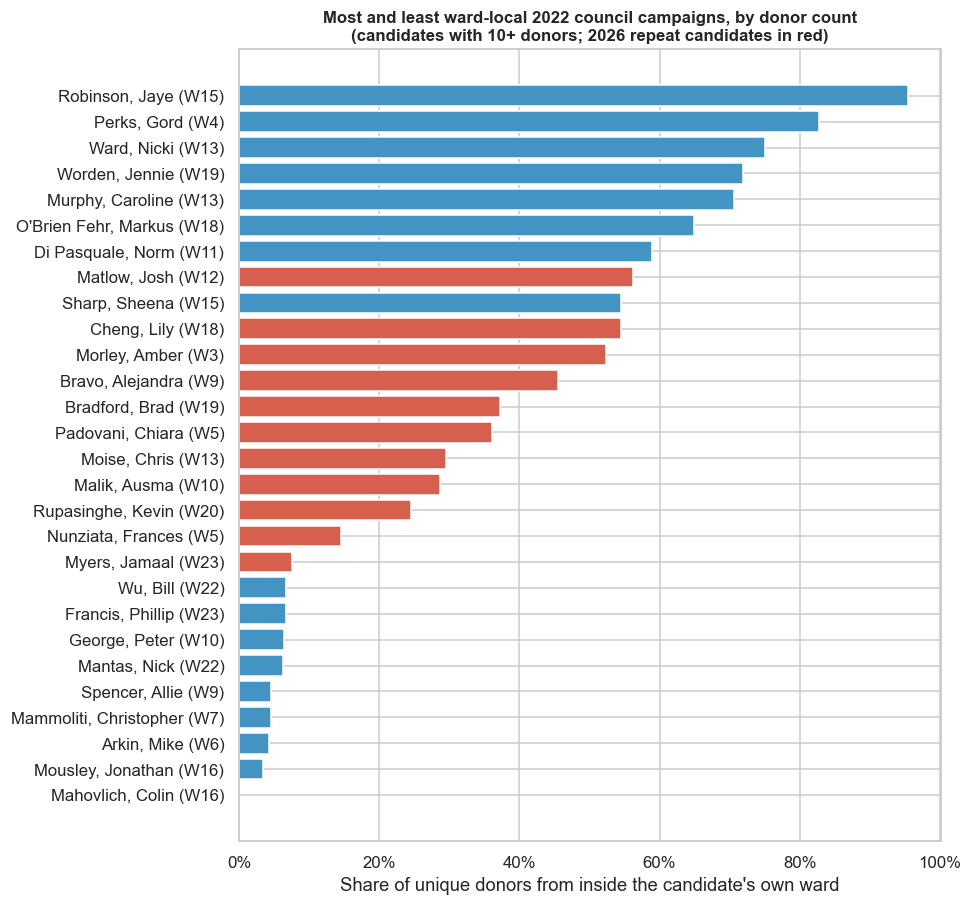

In [27]:
plot_local_share_ranking(
    council_local_profiles, "own_ward_donor_share",
    "Most and least ward-local 2022 council campaigns, by donor count\n(candidates with 10+ donors; 2026 repeat candidates in red)",
    "Share of unique donors from inside the candidate's own ward",
)


### A closer look at the four priority 2026 repeat council candidates

Bradford, Bravo, and Matlow all have well over 10 donors and appear in the rankings above.
Stephen Holyday does not — as Part 2 already flagged, his 2022 campaign had only 6 non-self-funded
donors, so any local-share percentage for him would be an artifact of a tiny sample rather than a
real fundraising pattern. We show his numbers anyway, with that caveat attached, because the
underlying fact (almost no outside donor base at all) is itself the finding.


In [28]:
priority_local_table = council_local_profiles.loc[
    council_local_profiles["candidate_raw"].isin(PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026)
].set_index("candidate_raw").loc[PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026]
priority_local_table[[
    "ward", "n_unique_donors", "own_ward_dollar_share", "elsewhere_toronto_dollar_share",
    "outside_toronto_dollar_share", "own_ward_donor_share", "median_own_ward_contribution",
    "median_elsewhere_toronto_contribution",
]]


,ward,n_unique_donors,own_ward_dollar_share,elsewhere_toronto_dollar_share,outside_toronto_dollar_share,own_ward_donor_share,median_own_ward_contribution,median_elsewhere_toronto_contribution
candidate_raw,,,,,,,,
"Bradford, Brad",19,153,0.36,0.50,0.14,0.37,500.00,500.00
"Bravo, Alejandra",9,231,0.47,0.49,0.04,0.45,250.00,250.00
"Matlow, Josh",12,208,0.61,0.38,0.01,0.56,250.00,250.00
"Holyday, Stephen",2,6,0.76,0.23,0.01,0.33,"1,200.00","1,200.00"


### The analogous question for 2023 mayor: Toronto versus outside Toronto

There's no ward for a mayoral candidate, so the relevant local/non-local split is simply Toronto
vs. outside Toronto — and, where useful, a coarser regional breakdown (Ontario outside Toronto vs.
the rest of Canada) inferred from the postal code's first letter (see `FSA_LETTER_TO_REGION` in
the constants cell). We don't push this further into a precise GTA/non-GTA split — the data can't
reliably support that distinction from a postal-code prefix alone.


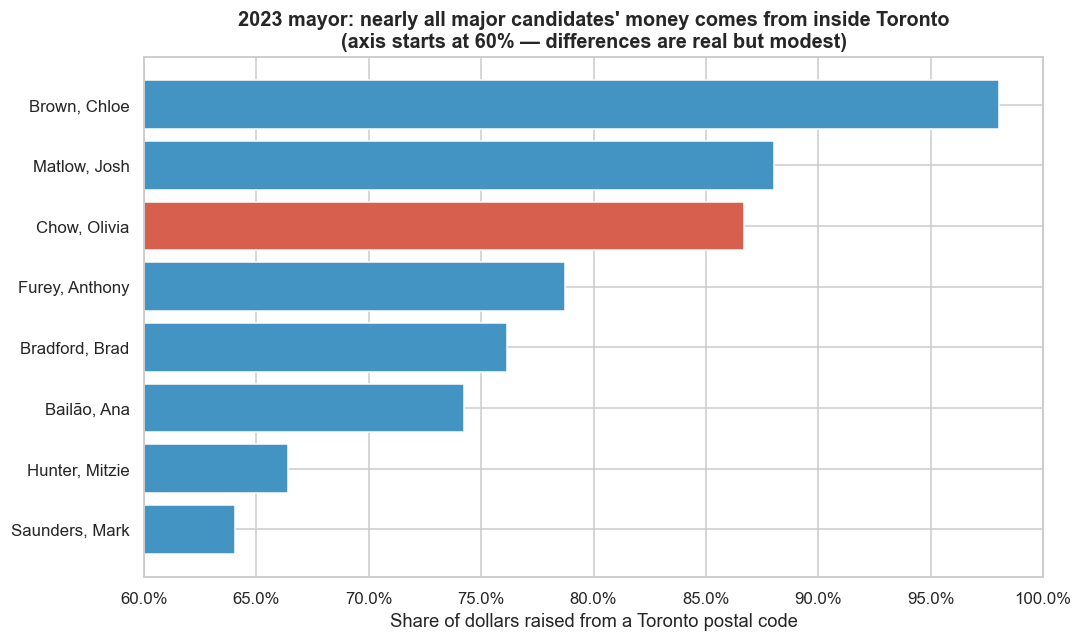

,toronto_dollar_share
candidate_raw,
"Saunders, Mark",0.64
"Hunter, Mitzie",0.66
"Bailão, Ana",0.74
"Bradford, Brad",0.76
"Furey, Anthony",0.79
"Chow, Olivia",0.87
"Matlow, Josh",0.88
"Brown, Chloe",0.98


In [29]:
def region_dollar_shares(df, candidate_col, candidates):
    rows = []
    for cand in candidates:
        sub = df.loc[df[candidate_col] == cand]
        shares = sub.groupby("region")["amount"].sum() / sub["amount"].sum()
        row = {"candidate_raw": cand, "toronto_dollar_share": shares.get("Toronto", 0.0)}
        rows.append(row)
    return pd.DataFrame(rows).set_index("candidate_raw")


mayor_region_shares = region_dollar_shares(mayor_2023, "candidate_raw", MAJOR_2023_CANDIDATES)
mayor_region_shares = mayor_region_shares.sort_values("toronto_dollar_share")

# Floating bars from a 60% baseline so the real (if modest) differences are visible, without
# the earlier bug of clipping bars whose value falls below the zoomed-in axis start.
baseline = 0.6
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors = [REPEAT_HIGHLIGHT_COLOR if normalize_name(c) in _norm_mayor_repeat else OTHER_CANDIDATE_COLOR
          for c in mayor_region_shares.index]
ax.barh(mayor_region_shares.index, mayor_region_shares["toronto_dollar_share"] - baseline, left=baseline, color=colors)
ax.set_xlabel("Share of dollars raised from a Toronto postal code")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(baseline, 1.0)
ax.set_title(f"2023 mayor: nearly all major candidates' money comes from inside Toronto\n(axis starts at {baseline:.0%} — differences are real but modest)")
plt.tight_layout()
plt.show()

mayor_region_shares


### Data-story potential — Part 4

- **This is one of the strongest angles in the notebook.** "How locally rooted is a councillor's
  money?" is intuitive, directly relevant to representation, and produces a genuinely wide, clean
  spread across candidates — from campaigns raising 90%+ of their money inside their own ward to
  campaigns raising almost none of it there. The ranked bar charts read immediately, with no
  further explanation needed.
- **The four priority 2026 repeat candidates already show real, distinct patterns without any
  cherry-picking:** Matlow's 2022 campaign was the most ward-rooted of the four (61% of dollars,
  56% of donors from Ward 12); Bravo's was closer to a 50/50 split between her own ward and the
  rest of Toronto; Bradford's was the most citywide of the three with enough donors to compare
  (half his dollars came from elsewhere in Toronto); and Holyday's tiny donor base (6 people,
  mostly family) makes any share statistic for him more a data-quality footnote than a comparable
  data point — worth stating plainly rather than papering over.
- **The 2023 mayoral Toronto-share comparison is a smaller, secondary finding**: real but modest
  differences (roughly 64%-98% Toronto-sourced across the majors), with Saunders and Hunter
  standing out as drawing the most from outside the city. Worth a mention, not a lead.
- **Caveat:** the FSA-centroid method can misclassify donors near a ward boundary, and a handful
  of very large suburban wards may show artificially higher "own-ward" shares than a finer
  geography would — this doesn't change which candidates sit at the extremes, but it's a genuine
  precision limit worth naming if this becomes a published piece.


## Part 5 — Demographics and political giving

**A resolution caveat that governs everything in this section.** Only the ~96-100 census tracts
that happen to contain the FSA centroid of at least one donor can carry a real
`donors_per_1000` / `dollars_per_capita` value under our geocoding method (Part 3). The other
~520 Toronto tracts show a mechanical zero that reflects the geocoding resolution, not an absence
of political giving there. Correlating demographics against a mix of real values and false zeros
would be misleading, so **this section restricts every demographic comparison to the roughly 96
tracts with a genuine donor match** — in effect, one representative tract per Toronto FSA. That
is a small-ish but usable sample for scatterplots, correlations, and a simple regression; it is
not a full census of all 622 Toronto tracts.

**Variable selection.** Rather than correlate dozens of available characteristics, we pick one or
two representative variables per conceptual group, all from the curated census pipeline
(`statcan_2021_ct_census_variables_master.csv`) except the two income/shelter-cost variables
pulled from `toronto-ct-small.csv` (see Part 3):

| Group | Variable(s) | Source |
|---|---|---|
| Population / urban form | `population_density_per_km2`, `age_65_plus_share` | curated master |
| Income / socioeconomic status | `median_individual_income` (2020, among recipients 15+), `low_income_lim_at_share` | small.csv / curated master |
| Housing | `renter_share`, `shelter_cost_30plus_share` (spending 30%+ of income on shelter) | curated master / small.csv |
| Education | `bachelors_or_higher_25_64_share` | curated master |
| Immigration / citizenship | `non_citizen_share`, `recent_immigrant_share` (arrived 2016-2021) | curated master |
| Racialized population | `visible_minority_share` | curated master |
| Mobility / commuting | `transit_commute_share` | curated master |

All variables are 0-1 shares (or a $ median / a density), as published by the curated pipeline,
so no additional transformation is needed beyond what the outcome variables get below.


In [30]:
DEMOGRAPHIC_VARS = [
    "population_density_per_km2", "age_65_plus_share",
    "median_individual_income", "low_income_lim_at_share",
    "renter_share", "shelter_cost_30plus_share",
    "bachelors_or_higher_25_64_share",
    "non_citizen_share", "recent_immigrant_share",
    "visible_minority_share", "transit_commute_share",
]
DEMOGRAPHIC_LABELS = {
    "population_density_per_km2": "Population density",
    "age_65_plus_share": "Share aged 65+",
    "median_individual_income": "Median individual income",
    "low_income_lim_at_share": "Low-income (LIM-AT) share",
    "renter_share": "Renter share",
    "shelter_cost_30plus_share": "Shelter-cost-burdened share",
    "bachelors_or_higher_25_64_share": "Bachelor's degree+ share",
    "non_citizen_share": "Non-citizen share",
    "recent_immigrant_share": "Recent immigrant share (2016-21)",
    "visible_minority_share": "Racialized (visible minority) share",
    "transit_commute_share": "Transit-commuting share",
}

# Combine both elections' contributions into one participation measure: a donor giving to both a
# council and a mayoral candidate is still counted once per tract, which is the point.
combined_cols = ["ctuid", "is_toronto_postal", "is_self_funded", "donor_id", "amount"]
combined_contributions = pd.concat([council_2022[combined_cols], mayor_2023[combined_cols]], ignore_index=True)
combined_ct_agg = with_per_capita(aggregate_to_ct(combined_contributions), ct_geo)

ct_demo = combined_ct_agg.loc[combined_ct_agg["n_unique_donors"] > 0].merge(
    ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], on="ctuid_norm", how="left"
)
ct_demo["log_dollars_per_capita"] = np.log1p(ct_demo["dollars_per_capita"])
ct_demo["log_donors_per_1000"] = np.log1p(ct_demo["donors_per_1000"])

print(f"ct_demo: {len(ct_demo)} census tracts with a genuine donor match "
      f"(of {len(ct_geo)} total Toronto tracts) and {ct_demo['population_total'].isna().sum()} missing population")
print(ct_demo[DEMOGRAPHIC_VARS].isna().sum())
ct_demo[["donors_per_1000", "dollars_per_capita"] + DEMOGRAPHIC_VARS].describe()


ct_demo: 96 census tracts with a genuine donor match (of 622 total Toronto tracts) and 0 missing population
population_density_per_km2         0
age_65_plus_share                  0
median_individual_income           0
low_income_lim_at_share            0
renter_share                       0
shelter_cost_30plus_share          0
bachelors_or_higher_25_64_share    0
non_citizen_share                  0
recent_immigrant_share             0
visible_minority_share             0
transit_commute_share              0
dtype: int64


,donors_per_1000,dollars_per_capita,population_density_per_km2,age_65_plus_share,median_individual_income,low_income_lim_at_share,renter_share,shelter_cost_30plus_share,bachelors_or_higher_25_64_share,non_citizen_share,recent_immigrant_share,visible_minority_share,transit_commute_share
count,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00
mean,32.48,27.04,"6,107.18",0.17,"45,781.25",0.12,0.41,0.29,0.52,0.15,0.06,0.50,0.24
std,44.74,35.01,"6,961.14",0.06,"13,989.89",0.06,0.22,0.09,0.18,0.08,0.04,0.24,0.08
min,1.12,0.92,87.80,0.04,"27,800.00",0.04,0.07,0.14,0.18,0.02,0.00,0.02,0.09
25%,8.75,7.50,"2,434.35",0.14,"34,400.00",0.07,0.23,0.23,0.38,0.09,0.03,0.28,0.18
50%,15.58,16.72,"4,123.10",0.17,"41,200.00",0.10,0.36,0.28,0.53,0.14,0.05,0.51,0.22
75%,40.49,29.29,"7,107.55",0.20,"54,500.00",0.15,0.57,0.34,0.68,0.20,0.08,0.68,0.28
max,258.76,201.12,"45,222.20",0.41,"87,000.00",0.29,1.00,0.52,0.87,0.38,0.17,0.95,0.47


### A. What neighbourhood characteristics are associated with financial participation?

We start with graphics, not regression output: a correlation heatmap across all the selected
variables plus the two outcomes, then scatterplots of the relationships that turn out to be
strongest. `dollars_per_capita` is heavily right-skewed (a few tracts have very high values), so
we use its log for correlations and plots.


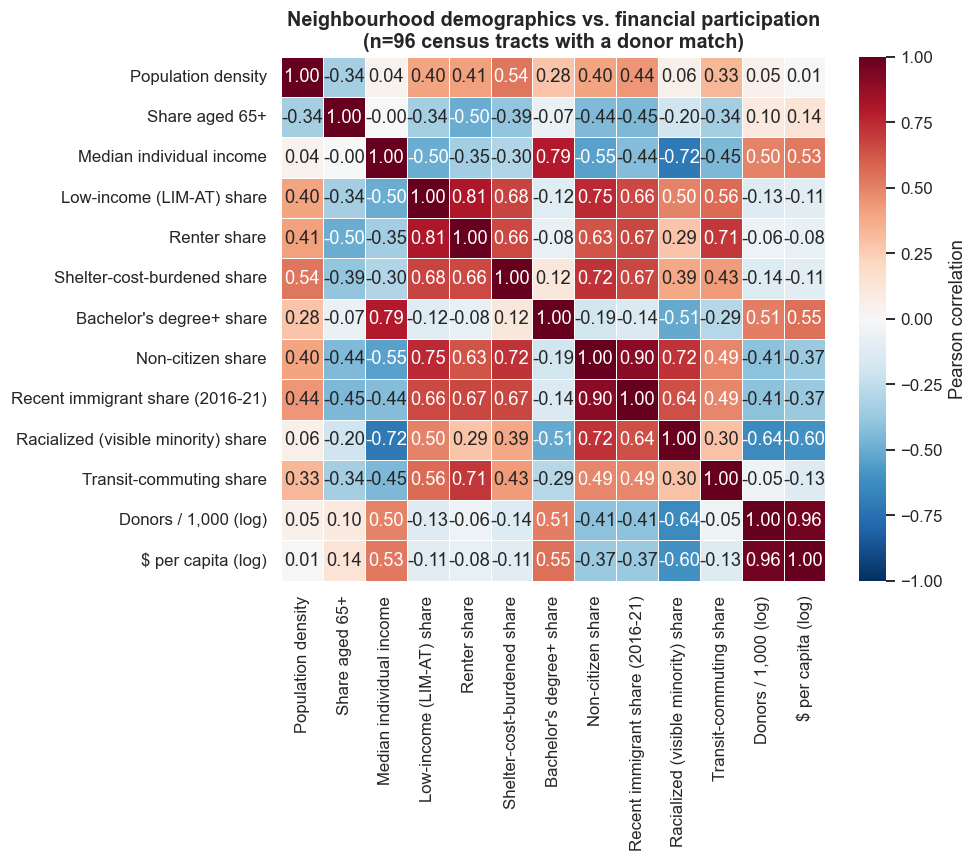

In [31]:
corr_cols = DEMOGRAPHIC_VARS + ["log_donors_per_1000", "log_dollars_per_capita"]
corr_labels = [DEMOGRAPHIC_LABELS.get(c, c) for c in DEMOGRAPHIC_VARS] + ["Donors / 1,000 (log)", "$ per capita (log)"]
corr_matrix = ct_demo[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Pearson correlation"})
ax.set_title(f"Neighbourhood demographics vs. financial participation\n(n={len(ct_demo)} census tracts with a donor match)")
plt.tight_layout()
plt.show()


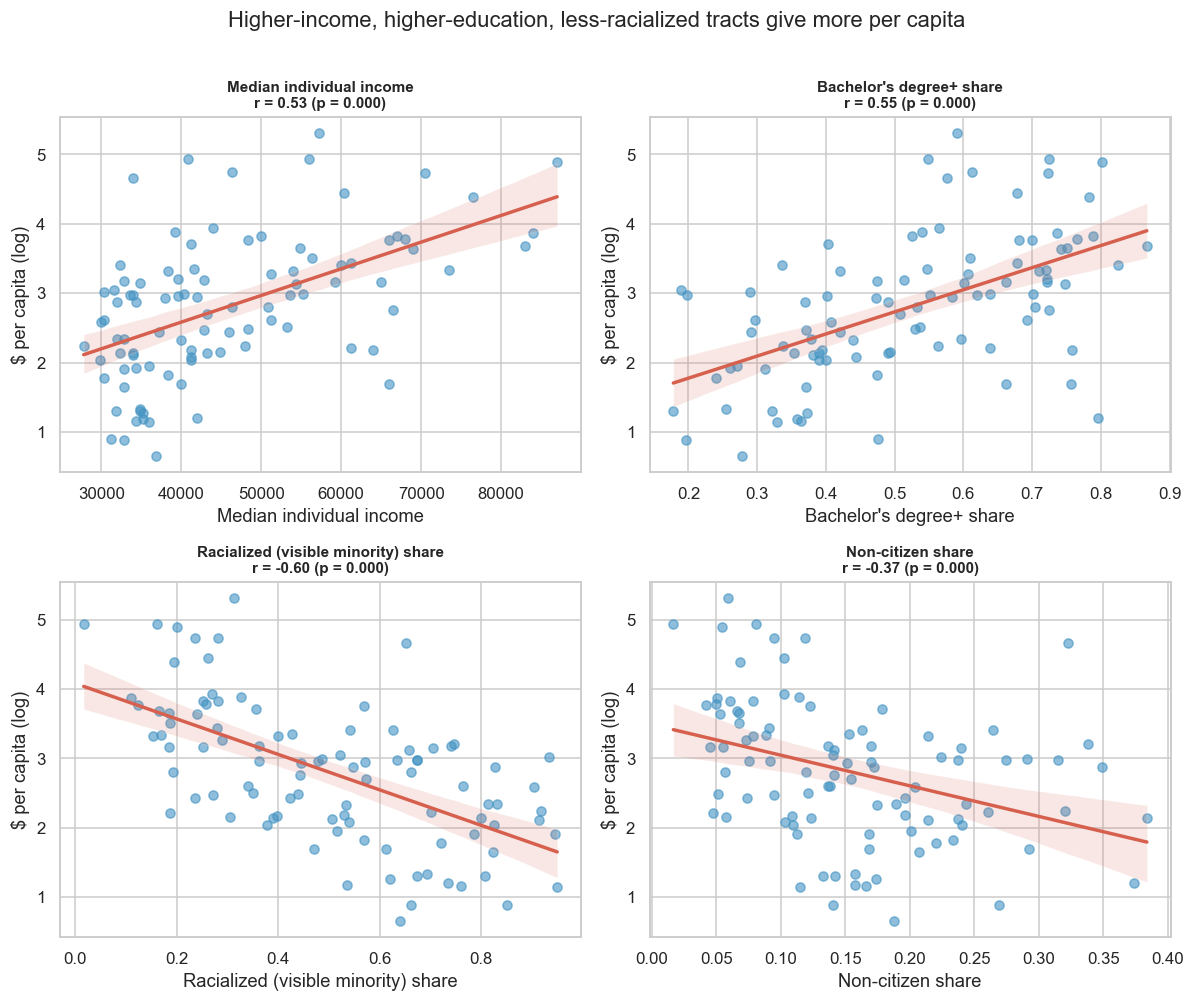

In [32]:
strongest_vars = ["median_individual_income", "bachelors_or_higher_25_64_share", "visible_minority_share", "non_citizen_share"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, var in zip(axes.flat, strongest_vars):
    sns.regplot(data=ct_demo, x=var, y="log_dollars_per_capita", ax=ax,
                scatter_kws={"alpha": 0.6, "color": OTHER_CANDIDATE_COLOR}, line_kws={"color": REPEAT_HIGHLIGHT_COLOR})
    r, p = stats.pearsonr(ct_demo[var], ct_demo["log_dollars_per_capita"])
    ax.set_title(f"{DEMOGRAPHIC_LABELS[var]}\nr = {r:.2f} (p = {p:.3f})", fontsize=10)
    ax.set_xlabel(DEMOGRAPHIC_LABELS[var])
    ax.set_ylabel("$ per capita (log)")
fig.suptitle("Higher-income, higher-education, less-racialized tracts give more per capita", y=1.01)
plt.tight_layout()
plt.show()


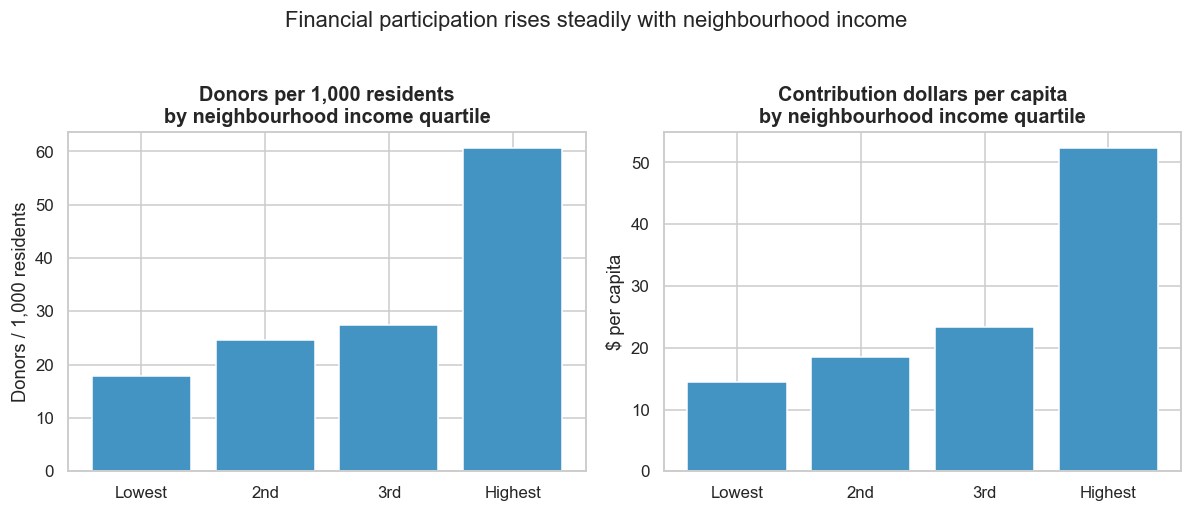

In [33]:
# A simpler, quantile-based view of the same income relationship, easier for a general reader
# than a scatterplot with a fitted line.
ct_demo["income_quartile"] = pd.qcut(ct_demo["median_individual_income"], 4, labels=["Lowest", "2nd", "3rd", "Highest"])
income_quartile_summary = ct_demo.groupby("income_quartile", observed=True)[["donors_per_1000", "dollars_per_capita"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(income_quartile_summary.index, income_quartile_summary["donors_per_1000"], color=OTHER_CANDIDATE_COLOR)
axes[0].set_title("Donors per 1,000 residents\nby neighbourhood income quartile")
axes[0].set_ylabel("Donors / 1,000 residents")
axes[1].bar(income_quartile_summary.index, income_quartile_summary["dollars_per_capita"], color=OTHER_CANDIDATE_COLOR)
axes[1].set_title("Contribution dollars per capita\nby neighbourhood income quartile")
axes[1].set_ylabel("$ per capita")
fig.suptitle("Financial participation rises steadily with neighbourhood income", y=1.03)
plt.tight_layout()
plt.show()


The scatterplots and the quantile chart agree with the heatmap: income and education are the
clearest positive associations, and racialized/non-citizen share are the clearest negative ones.
Population density, age 65+, and transit-commuting share showed weak, inconsistent correlations
in the heatmap and are not pursued further. Since several of the remaining candidate predictors
are highly correlated with each other (income, low-income share, and renter share all move
together), a small multivariate model is useful mainly to check whether income and education
still matter once we account for that overlap — not to claim a causal effect.


In [34]:
reg_vars = ["median_individual_income", "bachelors_or_higher_25_64_share", "visible_minority_share", "non_citizen_share"]
X = ct_demo[reg_vars].apply(lambda s: (s - s.mean()) / s.std())  # standardize so coefficients are comparable
X = sm.add_constant(X)
y = ct_demo["log_dollars_per_capita"]
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                              OLS Regression Results                              
Dep. Variable:     log_dollars_per_capita   R-squared:                       0.455
Model:                                OLS   Adj. R-squared:                  0.431
Method:                     Least Squares   F-statistic:                     18.99
Date:                    Mon, 17 Aug 2026   Prob (F-statistic):           2.20e-11
Time:                            16:31:13   Log-Likelihood:                -108.22
No. Observations:                      96   AIC:                             226.4
Df Residuals:                          91   BIC:                             239.3
Df Model:                               4                                         
Covariance Type:                nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

The model explains a substantial share of tract-to-tract variation (R² ≈ 0.46) with just four
standardized predictors. Once education and racialized share are in the model, **income's
independent contribution mostly disappears** — income and education are highly correlated with
each other (r = 0.79 in the heatmap above), and education turns out to be the variable doing the
real work. The two variables that remain independently significant are:

- **Bachelor's-degree share** (positive, p = 0.002): a one-standard-deviation increase in a
  tract's university-education rate is associated with roughly a 47% increase in dollars per
  capita (holding the others fixed), and
- **Racialized (visible-minority) share** (negative, p = 0.001): a one-standard-deviation increase
  is associated with roughly a 50% *decrease*.

This is a small, exploratory model on 96 tracts — not a causal claim — but the pattern is
consistent across every view in this section: **financial political participation in Toronto is
concentrated in highly-educated, disproportionately White/non-racialized neighbourhoods**, more
than it is simply a function of income.


### B. What kinds of neighbourhoods finance different candidates?

For each candidate, we take every Toronto contribution, look up the demographics of the census
tract its donor was assigned to (Part 3's FSA-centroid method), and compute a **dollar-weighted**
average of each demographic variable — effectively, "what does the average dollar funding this
campaign look like, in neighbourhood terms?" We then express each variable as a z-score relative
to the Toronto-wide tract average, so a candidate profile of all zeros would mean "demographically
identical to Toronto as a whole," and positive/negative values show which direction and how far a
candidate's funding base leans.

> **This is ecological, not individual, description.** A high average income in the tracts
> funding a candidate says something about *the neighbourhoods* the money came from — it says
> nothing about any individual donor's income, immigration status, or race, and it should never be
> read as such.


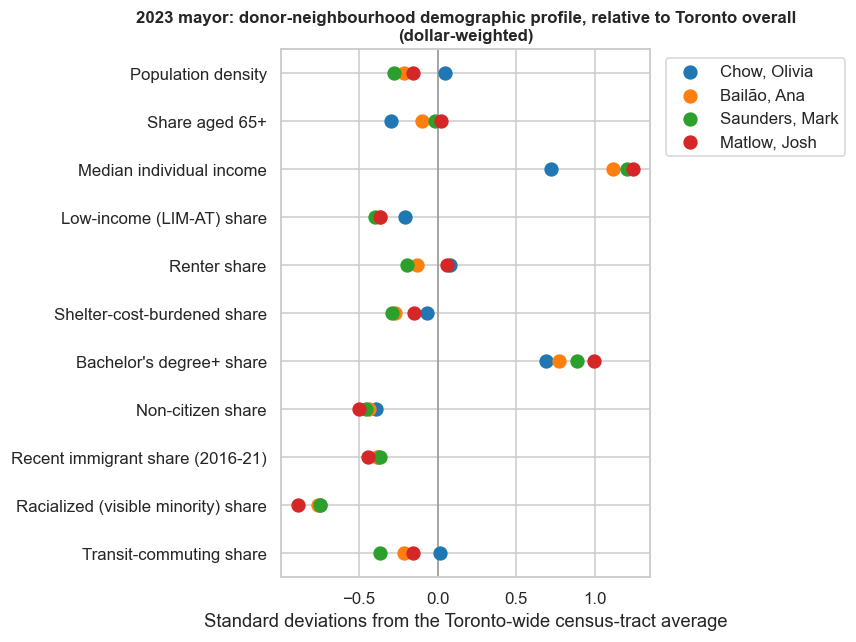

In [35]:
toronto_wide_mean = ct_geo[DEMOGRAPHIC_VARS].mean()
toronto_wide_std = ct_geo[DEMOGRAPHIC_VARS].std()


def candidate_demographic_zprofile(df, candidate_col, candidate_value):
    sub = df.loc[(df[candidate_col] == candidate_value) & df["is_toronto_postal"] & df["ctuid"].notna()].copy()
    sub["ctuid_norm"] = sub["ctuid"].apply(normalize_ctuid)
    sub = sub.merge(ct_geo[["ctuid_norm"] + DEMOGRAPHIC_VARS], on="ctuid_norm", how="left")
    weighted = sub[DEMOGRAPHIC_VARS].multiply(sub["amount"], axis=0).sum() / sub["amount"].sum()
    return (weighted - toronto_wide_mean) / toronto_wide_std


def plot_candidate_profiles(df, candidate_col, candidates, title):
    profiles = pd.DataFrame({cand: candidate_demographic_zprofile(df, candidate_col, cand) for cand in candidates})
    profiles.index = [DEMOGRAPHIC_LABELS[v] for v in profiles.index]

    fig, ax = plt.subplots(figsize=(8, 6))
    palette = sns.color_palette("tab10", len(candidates))
    y_pos = np.arange(len(profiles.index))
    for i, cand in enumerate(candidates):
        ax.scatter(profiles[cand], y_pos, label=cand, color=palette[i], s=70, zorder=3)
    ax.axvline(0, color=NEUTRAL_GRAY, linewidth=1)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(profiles.index)
    ax.set_xlabel("Standard deviations from the Toronto-wide census-tract average")
    ax.set_title(title, fontsize=11)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return profiles


mayor_contrast_candidates = ["Chow, Olivia", "Bailão, Ana", "Saunders, Mark", "Matlow, Josh"]
mayor_profile_table = plot_candidate_profiles(
    mayor_2023, "candidate_raw", mayor_contrast_candidates,
    "2023 mayor: donor-neighbourhood demographic profile, relative to Toronto overall\n(dollar-weighted)",
)


**A striking result: the four candidates look far more alike than different.** Every one of them
draws disproportionately from higher-income, highly-educated, less-racialized tracts relative to
Toronto overall — even Chow, whose top individual postal areas in Part 3 looked more mixed than
her opponents'. The *degree* differs modestly (Chow's profile is consistently the least extreme
of the four; Bailão and Saunders are nearly identical), but the *direction* is the same for
everyone. That's a meaningful finding in its own right: **whoever a Toronto mayoral candidate is,
their financial constituency looks like Toronto's wealthiest, most educated neighbourhoods far
more than it looks like the median ward.**


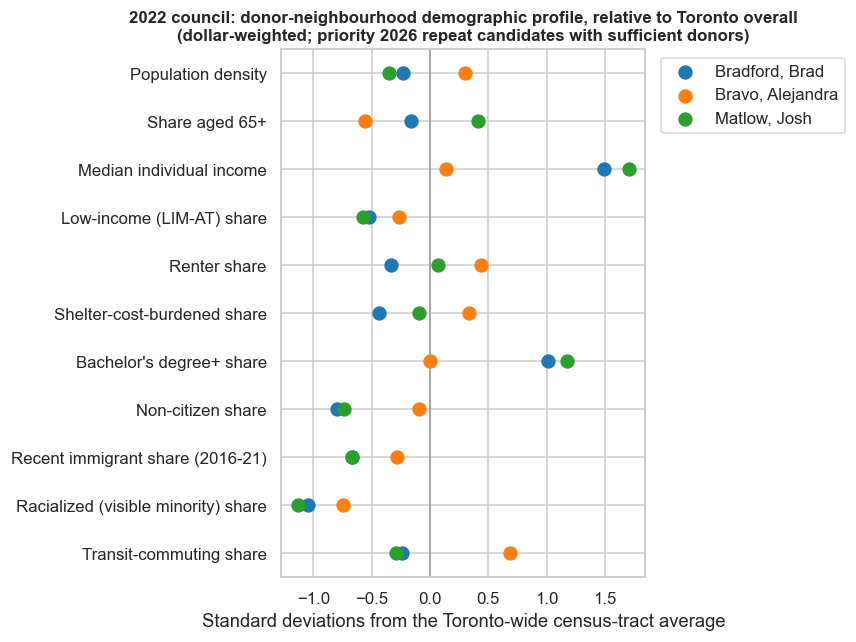

In [36]:
# Same exercise for council: the three priority 2026 repeat candidates with enough donors for a
# stable profile. Holyday is excluded here (6 donors, mostly family — see Part 2) since a
# demographic average over that few donors would be noise, not signal.
council_contrast_candidates = ["Bradford, Brad", "Bravo, Alejandra", "Matlow, Josh"]
council_profile_table = plot_candidate_profiles(
    council_2022, "candidate_raw", council_contrast_candidates,
    "2022 council: donor-neighbourhood demographic profile, relative to Toronto overall\n(dollar-weighted; priority 2026 repeat candidates with sufficient donors)",
)


Unlike the mayoral comparison, this one shows genuine separation. **Bravo's donor base looks
close to an average Toronto neighbourhood** — modest income (+0.15 SD), above-average renter and
transit-commuting shares, a much smaller racialized-share gap (-0.2 SD) — while **Bradford's and
Matlow's donor bases are both drawn overwhelmingly from the wealthiest, most-educated, least-
racialized tracts in the city** (income and education both 1-1.6 SD above the Toronto tract
average, racialized share about 1 SD below). Bradford and Matlow otherwise represent very
different councillor profiles, so the fact that their fundraising *demographics* land in nearly
the same place — while Bravo's does not — is a genuinely useful contrast for a 2026-oriented story.


### Data-story potential — Part 5

- **"Political giving is concentrated in wealthy, highly-educated, disproportionately non-
  racialized neighbourhoods" is a strong, well-supported, and intuitive finding.** It holds up
  across a correlation heatmap, scatterplots, a quantile chart, and a small regression, with a
  magnitude (R² ≈ 0.46 from just two variables once collinearity is untangled) that a reader can
  take seriously. It also connects directly and uncomfortably to representation: it says municipal
  candidates are financially answerable, disproportionately, to a narrow slice of the city.
- **The nuance that education — not income per se — is the more independent predictor** is a
  genuinely interesting refinement worth keeping in any write-up, rather than defaulting to the
  simpler (and by itself insufficient) "rich neighbourhoods give more" framing.
- **The candidate-profile comparison splits into two different results depending on race.** 2023
  mayoral candidates all look demographically similar to each other despite very different
  politics — a "money talks the same language regardless of candidate" finding. 2022 council
  candidates show real separation (Bravo's donor base looks like an average Toronto neighbourhood;
  Bradford's and Matlow's look like Toronto's wealthiest tracts) — a "your councillor's donor base
  can look nothing like your ward" finding. Both are worth keeping, but they're different claims
  and should not be blended into one headline.
- **Caveats to carry forward:** this is ecological, not individual-level, analysis; the underlying
  geography is FSA-resolution, restricted to the ~96 tracts with a genuine donor match; and the
  regression is a small, exploratory, non-causal model.


## Part 6 — Fundraising timeline and momentum

The 2023 by-election ran from the April 2023 nomination period to the June 26, 2023 vote (a small
number of trailing contributions continue past that, presumably late-filed or loan-related). We
build weekly dollars, weekly unique donors, and cumulative versions of both for the major
candidates, with particular attention to Olivia Chow given her 2026 candidacy.


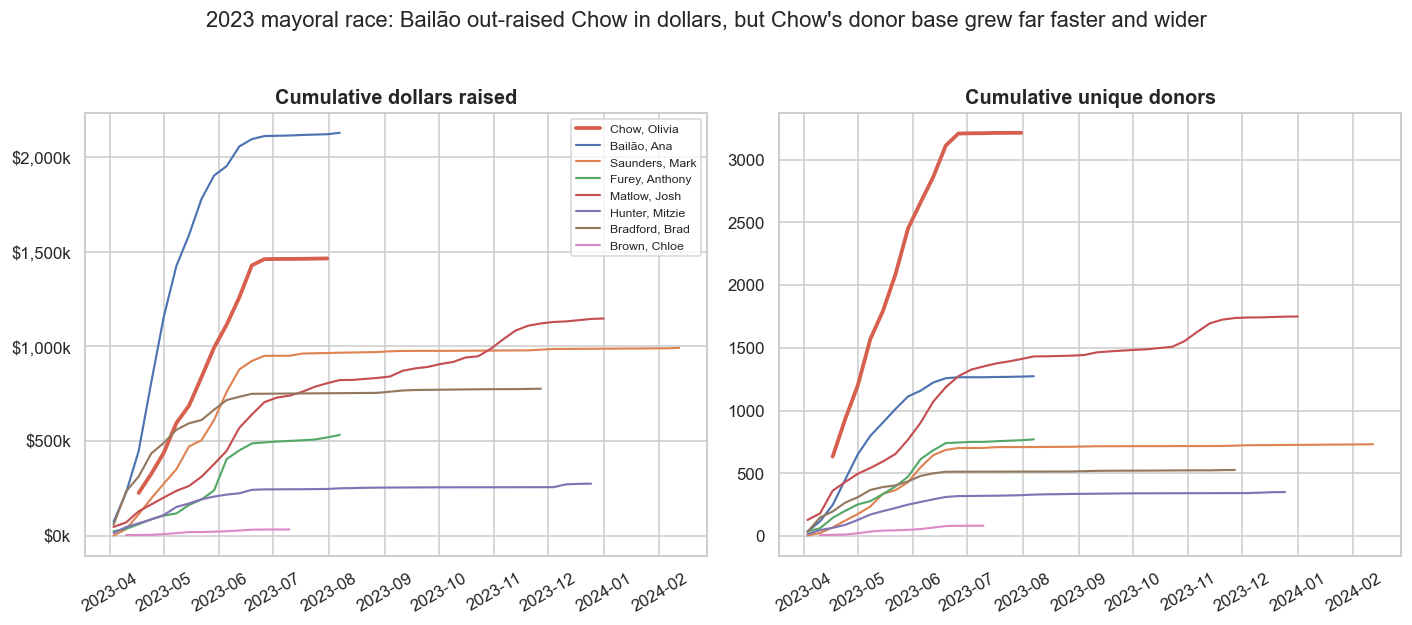

In [37]:
def weekly_timeline(df, candidate_col, candidate_value):
    sub = df.loc[df[candidate_col] == candidate_value].copy()
    sub["week"] = sub["date_received"].dt.to_period("W").dt.start_time
    weekly = sub.groupby("week").agg(weekly_amount=("amount", "sum"), weekly_contributions=("amount", "size"))
    donors_by_week = sub.loc[~sub["is_self_funded"]].drop_duplicates(["donor_id"]).groupby("week").size()
    weekly["weekly_new_donor_appearances"] = donors_by_week.reindex(weekly.index).fillna(0)
    weekly["cumulative_amount"] = weekly["weekly_amount"].cumsum()
    # Cumulative *unique* donors requires tracking first-seen week per donor, not a running sum of weekly counts.
    first_seen = sub.loc[~sub["is_self_funded"]].groupby("donor_id")["week"].min()
    cum_new_donors = first_seen.value_counts().sort_index().cumsum()
    weekly["cumulative_unique_donors"] = cum_new_donors.reindex(weekly.index, method="ffill").fillna(0)
    return weekly.reset_index()


mayor_timelines = {cand: weekly_timeline(mayor_2023, "candidate_raw", cand) for cand in MAJOR_2023_CANDIDATES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for cand in MAJOR_2023_CANDIDATES:
    tl = mayor_timelines[cand]
    color = REPEAT_HIGHLIGHT_COLOR if normalize_name(cand) in _norm_mayor_repeat else None
    lw = 2.5 if color else 1.4
    axes[0].plot(tl["week"], tl["cumulative_amount"], label=cand, color=color, linewidth=lw)
    axes[1].plot(tl["week"], tl["cumulative_unique_donors"], label=cand, color=color, linewidth=lw)
axes[0].set_title("Cumulative dollars raised")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
axes[1].set_title("Cumulative unique donors")
axes[0].legend(fontsize=8)
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("2023 mayoral race: Bailão out-raised Chow in dollars, but Chow's donor base grew far faster and wider", y=1.03)
plt.tight_layout()
plt.show()


**This is not the result we expected going in, and it's a better story for it.** Ana Bailão
actually raised more total money than Olivia Chow over the campaign (~$2.1M vs. ~$1.47M) — but
Chow's donor base grew both faster and to roughly 2.5x the final size (3,200+ unique donors vs.
Bailão's ~1,300). Both candidates' fundraising was essentially over by early July, consistent
with the June 26 vote; the "reaching further into 2023-24" tail on plots for candidates like
Matlow and Saunders is a small number of late/loan-related entries, not real late-campaign
momentum. **Two different, defensible claims come out of this same chart**: "Bailão raised more
money" and "Chow built the broadest donor base by a wide margin" are both true, and a story
should be precise about which one it's making.


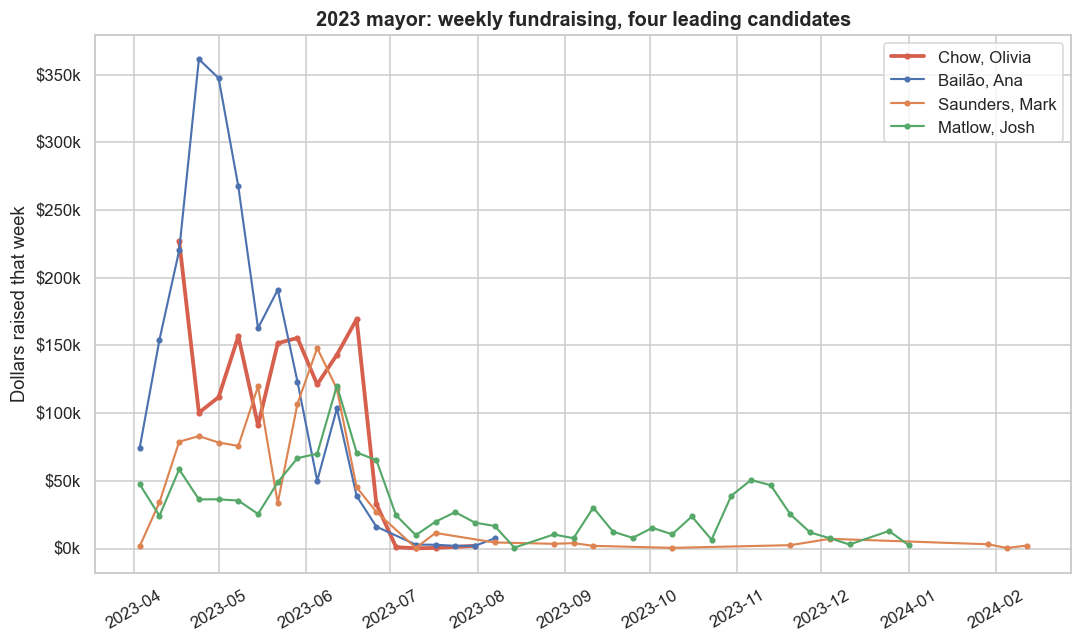

In [38]:
# Weekly (non-cumulative) dollars, to see momentum, spikes, and whether fundraising was front-
# loaded or built gradually — the cumulative view above can hide this.
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for cand in ["Chow, Olivia", "Bailão, Ana", "Saunders, Mark", "Matlow, Josh"]:
    tl = mayor_timelines[cand]
    color = REPEAT_HIGHLIGHT_COLOR if normalize_name(cand) in _norm_mayor_repeat else None
    lw = 2.5 if color else 1.4
    ax.plot(tl["week"], tl["weekly_amount"], label=cand, color=color, linewidth=lw, marker="o", markersize=3)
ax.set_title("2023 mayor: weekly fundraising, four leading candidates")
ax.set_ylabel("Dollars raised that week")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}k"))
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


Bailão's fundraising was front-loaded around a single, very large early spike (weeks of
mid-to-late April, $350k+/week) that faded quickly; Chow's was more evenly sustained across the
whole campaign, with two comparable peaks (mid-April and mid-June) rather than one dominant
launch week. Matlow shows a long, low-level tail into late 2023 that the other candidates don't —
plausibly post-election wind-down activity rather than live campaign momentum.

**Connecting timeline to geography:** does a campaign's donor base broaden geographically as it
gains momentum? We check this only for Chow vs. Bailão, since Part 3 already showed a real
geographic contrast between them worth following up.


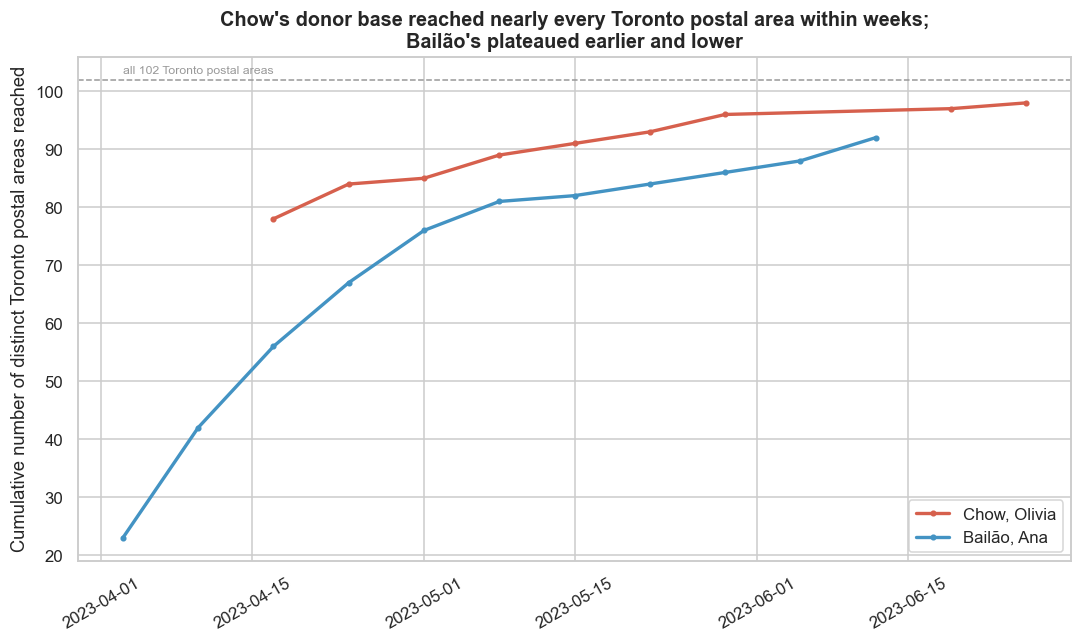

In [39]:
def cumulative_fsa_reach(df, candidate_col, candidate_value):
    sub = df.loc[(df[candidate_col] == candidate_value) & df["is_toronto_postal"]].copy()
    sub["week"] = sub["date_received"].dt.to_period("W").dt.start_time
    first_seen = sub.groupby("fsa")["week"].min()
    return first_seen.value_counts().sort_index().cumsum()


fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for cand, color in [("Chow, Olivia", REPEAT_HIGHLIGHT_COLOR), ("Bailão, Ana", OTHER_CANDIDATE_COLOR)]:
    reach = cumulative_fsa_reach(mayor_2023, "candidate_raw", cand)
    ax.plot(reach.index, reach.values, label=cand, color=color, linewidth=2.2, marker="o", markersize=3)
ax.axhline(n_toronto_fsas_total, color=NEUTRAL_GRAY, linestyle="--", linewidth=1)
ax.text(reach.index.min(), n_toronto_fsas_total + 1, f"all {n_toronto_fsas_total} Toronto postal areas", fontsize=8, color=NEUTRAL_GRAY)
ax.set_ylabel("Cumulative number of distinct Toronto postal areas reached")
ax.set_title("Chow's donor base reached nearly every Toronto postal area within weeks;\nBailão's plateaued earlier and lower")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()


### Data-story potential — Part 6

- **"Bailão raised more money, but Chow built a much bigger, broader donor base" is a strong,
  surprising, and easy-to-visualize finding.** It survives across three different views (cumulative
  dollars, cumulative donors, and geographic reach), which is exactly the kind of convergent
  evidence that makes a chart trustworthy rather than a one-off artifact.
- **The weekly view adds real texture**: Bailão's fundraising was a single early spike that faded
  fast, while Chow's was more sustained across the campaign — a "launched big vs. built steadily"
  contrast that a reader can see immediately in the line shapes.
- **Geographic breadth tracks donor-count breadth, not dollar totals** — Chow's donor base reached
  nearly all of Toronto's postal areas within the first few weeks, while Bailão's expanded more
  gradually and stopped growing earlier and short of full coverage. This is a reasonable, if
  secondary, "momentum broadens the map" result, worth keeping as a supporting panel rather than
  a standalone headline.
- **Caveat:** a small number of very late (post-election) entries for some candidates reflect
  wind-down administrative activity, not real campaign momentum, and were not filtered out — they
  are visually obvious as flat, low tails and don't affect the campaign-period conclusions above.


## Part 7 — Cross-election donor overlap, 2022 → 2023

We already built a conservative donor identifier for exactly this purpose: `donor_id`, a
normalized name plus full postal code (Part 1). This is deliberately cautious — no fuzzy matching,
no partial-name matching — so it will under-count real repeat donors (anyone who moved, or whose
name was entered inconsistently, won't match) rather than over-count them via false positives from
common names. Given that, any overlap we do find is a reasonably solid floor, not an inflated
estimate.


In [40]:
council_donor_ids = set(council_2022.loc[~council_2022["is_self_funded"], "donor_id"])
mayor_donor_ids = set(mayor_2023.loc[~mayor_2023["is_self_funded"], "donor_id"])
overlap_donor_ids = council_donor_ids & mayor_donor_ids

print(f"2022 council donors: {len(council_donor_ids):,}")
print(f"2023 mayor donors:   {len(mayor_donor_ids):,}")
print(f"Donors appearing in both: {len(overlap_donor_ids):,} "
      f"({len(overlap_donor_ids)/len(council_donor_ids):.0%} of council donors, "
      f"{len(overlap_donor_ids)/len(mayor_donor_ids):.0%} of mayoral donors)")


2022 council donors: 5,287
2023 mayor donors:   8,935
Donors appearing in both: 884 (17% of council donors, 10% of mayoral donors)


### Where did Bradford's and Matlow's own 2022 council donors go in 2023?

Both ran for mayor in 2023 themselves — the most direct version of the cross-election question.


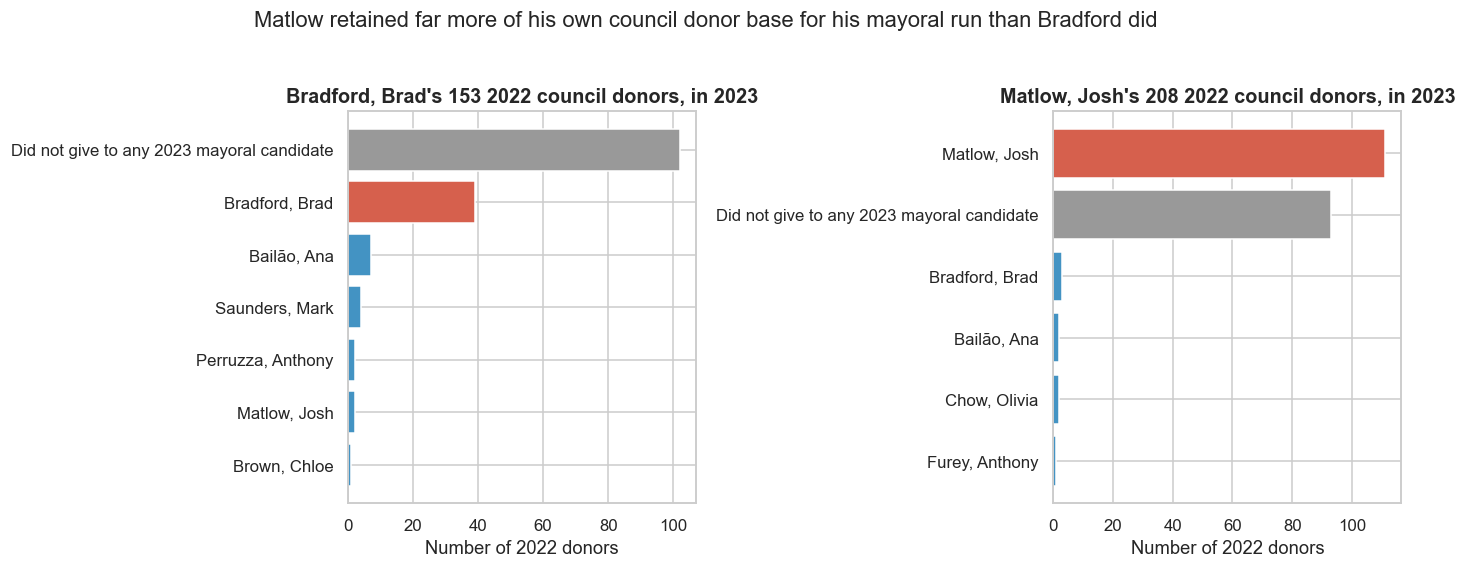

In [41]:
def own_donor_destinations(council_candidate, n_top=6):
    own_donors = set(council_2022.loc[
        (council_2022["candidate_raw"] == council_candidate) & (~council_2022["is_self_funded"]), "donor_id"
    ])
    gave_in_2023 = mayor_2023.loc[mayor_2023["donor_id"].isin(own_donors) & (~mayor_2023["is_self_funded"])]
    destinations = gave_in_2023.groupby("candidate_raw")["donor_id"].nunique().sort_values(ascending=False)
    n_gave_2023 = gave_in_2023["donor_id"].nunique()
    result = destinations.head(n_top).copy()
    result["Did not give to any 2023 mayoral candidate"] = len(own_donors) - n_gave_2023
    return len(own_donors), result


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cand in zip(axes, ["Bradford, Brad", "Matlow, Josh"]):
    n_donors, dest = own_donor_destinations(cand)
    dest = dest.sort_values()
    colors = [NEUTRAL_GRAY if "Did not" in i else (REPEAT_HIGHLIGHT_COLOR if i == cand else OTHER_CANDIDATE_COLOR) for i in dest.index]
    ax.barh(dest.index, dest.values, color=colors)
    ax.set_title(f"{cand}'s {n_donors} 2022 council donors, in 2023")
    ax.set_xlabel("Number of 2022 donors")
fig.suptitle("Matlow retained far more of his own council donor base for his mayoral run than Bradford did", y=1.03)
plt.tight_layout()
plt.show()


### Did particular council donor networks flow into particular 2023 mayoral campaigns?

For council candidates with at least 30 donors, we compute the percentage of each one's 2022
donors who also gave to each major 2023 mayoral candidate.


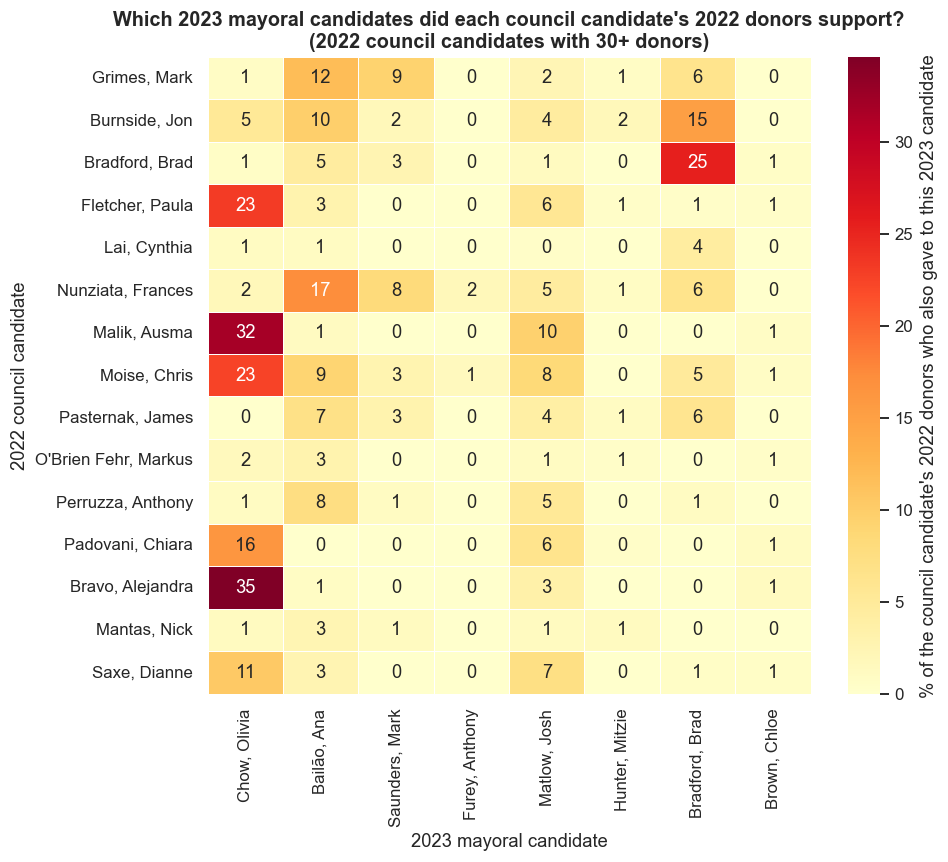

In [42]:
eligible_council = [
    cand for cand in council_profiles.sort_values("total_amount", ascending=False)["candidate_raw"]
    if council_profiles.set_index("candidate_raw").loc[cand, "n_unique_donors"] >= MIN_DONORS_FOR_OVERLAP_MATRIX
][:15]

overlap_rows = []
for cc in eligible_council:
    own = set(council_2022.loc[(council_2022["candidate_raw"] == cc) & (~council_2022["is_self_funded"]), "donor_id"])
    row = {}
    for mc in MAJOR_2023_CANDIDATES:
        their = set(mayor_2023.loc[(mayor_2023["candidate_raw"] == mc) & (~mayor_2023["is_self_funded"]), "donor_id"])
        row[mc] = 100 * len(own & their) / len(own) if own else np.nan
    overlap_rows.append(row)
overlap_matrix = pd.DataFrame(overlap_rows, index=eligible_council)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(overlap_matrix, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "% of the council candidate's 2022 donors who also gave to this 2023 candidate"})
ax.set_title("Which 2023 mayoral candidates did each council candidate's 2022 donors support?\n(2022 council candidates with 30+ donors)")
ax.set_xlabel("2023 mayoral candidate")
ax.set_ylabel("2022 council candidate")
plt.tight_layout()
plt.show()


The pattern is clean and politically legible. **Bravo (35%) and Malik (32%)** — both progressive
councillors — had by far their strongest donor overlap with **Chow**. **Grimes (12%), Burnside
(15% with Bradford, 10% with Bailão), and Nunziata (17%)** — more moderate/centrist councillors —
overlapped more with **Bailão** and, for Burnside, with **Bradford** himself. Bradford's own
donors mostly went to Bradford (25%, consistent with the self-continuity chart above) with a
smaller secondary flow to Bailão (5%). Furey, Hunter, and Brown barely register anywhere in this
matrix — their support bases don't appear to have meaningfully overlapped with any of these
council candidates' donor networks.

### Data-story potential — Part 7

- **This is one of the more novel, harder-to-find-elsewhere findings in the notebook.** It
  directly answers "did council fundraising networks flow into particular mayoral campaigns?"
  with real, non-trivial numbers (roughly a third of Bravo's and Malik's donors also gave to
  Chow), using a deliberately conservative matching method — this isn't a coincidence-prone fuzzy
  match.
- **It lines up with what's publicly known about these councillors' political alignments**,
  which is exactly the kind of "the data confirms a story a reader already half-suspects, with
  real numbers behind it" result that works well in publication.
- **Bradford vs. Matlow donor retention (25% vs. 53%) is a clean, self-contained two-bar
  comparison** that stands on its own and previews Part 8's repeat-candidate framing.
- **Caveats:** matching is name+postal-code based and will miss real repeat donors who moved or
  whose name was entered differently; a handful of very common names could in principle produce a
  false match, though the postal-code component makes that unlikely to matter at this scale. The
  overlap percentages describe *donor* counts, not dollars, and should not be read as vote
  transfers — donating is not voting.


## Part 8 — What the historical data says about 2026 repeat candidates

This section doesn't run new analysis so much as **pull together everything above that is
specific to Olivia Chow and the four priority 2026 council repeat candidates**, since that's the
whole point of the exercise.

### Olivia Chow: the central 2026 mayoral story

- **Fundraising scale:** $1.46M raised from 3,214 unique donors (Part 2/6) — the largest donor
  base of any 2023 candidate by a wide margin (more than 1,000 donors ahead of second-place
  Matlow at 1,750), even though Ana Bailão raised more total money (~$2.1M) (Part 6).
- **Donor concentration:** a Gini of 0.47 across her donors and a top-10-donor share of just
  1.7% — squarely in the middle of the major-candidate range (Bailão and Bradford were less
  concentrated; Furey, Hunter, and Matlow were somewhat more) and nowhere close to being reliant
  on a small number of big donors.
- **Geography:** donors in 98 of ~102 Toronto postal areas, the widest reach of any major
  candidate (Part 3); her top-5 postal areas are a middling ~23% of her money, and include more
  mixed, gentrifying west-end areas (Christie, Bloorcourt) alongside established wealthy ones —
  slightly more varied than Bailão's, whose top areas are almost uniformly Rosedale/Forest
  Hill/Yonge-Eglinton (Part 3).
- **Toronto vs. outside:** 87% of her dollars came from Toronto postal codes, near the middle of
  the major-candidate range (Part 4).
- **Demographic profile:** like every major 2023 candidate, her donor base skews toward higher-
  income, highly-educated, less-racialized tracts relative to Toronto overall — but she is
  consistently the *least* skewed of the four candidates compared in Part 5 (still far from
  representative of an average tract, just less extreme than Bailão, Saunders, or Matlow).
- **Momentum:** a sustained, two-peaked fundraising pattern (mid-April and mid-June) rather than
  one dominant launch spike, and the fastest, widest early geographic expansion of any major
  candidate (Part 6).
- **Cross-election ties:** among 2022 council candidates with 30+ donors, **Bravo (35%) and Malik
  (32%)** show by far the strongest donor overlap with Chow — a concrete, named link between
  specific council networks and her mayoral base (Part 7).

**Bottom line for 2026:** Chow's 2023 fundraising was defined far more by breadth (most donors,
widest geography, fastest expansion, middling donor concentration) than by being untouched by the
same wealthy-neighbourhood tilt every major candidate showed. Both things can be — and were —
true at once.


### The four priority 2026 council repeat candidates: fundamentally different donor networks?

We assemble one compact table from everything already computed in Parts 2 and 4 for Bradford,
Bravo, Matlow, and Holyday.


In [43]:
priority_summary = council_profiles.set_index("candidate_raw").loc[PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026, [
    "ward", "total_amount", "n_unique_donors", "median_contribution", "gini_donor_totals", "top10_donor_share",
]].join(
    council_local_profiles.set_index("candidate_raw").loc[PRIORITY_REPEAT_COUNCIL_CANDIDATES_2026, [
        "own_ward_dollar_share", "outside_toronto_dollar_share",
    ]]
)
priority_summary["own_ward_dollar_share"] = priority_summary["own_ward_dollar_share"].map(lambda x: f"{x:.0%}")
priority_summary["outside_toronto_dollar_share"] = priority_summary["outside_toronto_dollar_share"].map(lambda x: f"{x:.0%}")
priority_summary["top10_donor_share"] = priority_summary["top10_donor_share"].map(lambda x: f"{x:.0%}")
priority_summary


,ward,total_amount,n_unique_donors,median_contribution,gini_donor_totals,top10_donor_share,own_ward_dollar_share,outside_toronto_dollar_share
candidate_raw,,,,,,,,
"Bradford, Brad",19,"102,166.00",153,500.00,0.30,12%,36%,14%
"Bravo, Alejandra",9,"83,689.45",231,250.00,0.31,15%,47%,4%
"Matlow, Josh",12,"81,200.82",208,250.00,0.43,15%,61%,1%
"Holyday, Stephen",2,"15,798.09",6,"1,200.00",0.13,100%,76%,1%


**Yes — these four built genuinely different kinds of donor networks, not just different-sized
ones.** Putting this table together with the demographic profile in Part 5:

- **Bradford** raised the most money with a moderate donor base (153 donors), the *least*
  ward-local of the three comparable candidates (36% of dollars from Ward 19, half from elsewhere
  in Toronto), and the highest outside-Toronto share (14%) — a citywide-leaning network for a
  sitting councillor.
- **Bravo** built the largest donor base relative to money raised (231 donors on a smaller total),
  a roughly even ward-local/citywide split, and — uniquely among the three — a donor-neighbourhood
  demographic profile close to an average Toronto tract rather than a wealthy one.
- **Matlow** was the most ward-rooted of the three (61% of dollars, largest Gini/top-10 share of
  the group, so somewhat more donor-concentrated too) — a locally-anchored, donor-concentrated
  profile that also carried into his 2023 mayoral run, where he retained 53% of his own council
  donors (Part 7), more than double Bradford's 25%.
- **Holyday** is the outlier that isn't really comparable: 6 non-family donors and 100% self/family
  funding is a fundamentally different mode of campaign financing — closer to "doesn't rely on
  a donor network at all" than any variation on the other three.

### Data-story potential — Part 8

- **This section is a synthesis, not a new analysis**, so its story potential rides entirely on
  the strength of the pieces feeding into it — which, per the assessments above, are mostly
  **strong** (Part 4's local-share ranking, Part 7's donor-overlap heatmap, Part 6's Chow-vs-
  Bailão contrast) with a couple of **moderate** supporting details (Part 5's demographic tilt,
  which is shared across almost everyone).
- **The clearest single 2026-oriented headline the notebook supports:** Toronto's returning
  candidates enter 2026 with historically very different fundraising machines — Chow's is broad
  and donor-heavy; Bradford's is the most citywide/least ward-rooted of the council repeats;
  Bravo's is the most demographically representative; Matlow's is the most locally concentrated
  and most loyal to itself across elections; Holyday barely has one at all in the conventional
  sense.
- **Caveat:** none of this predicts 2026 fundraising, which will happen under different rules,
  different opponents, and (for Chow) incumbency rather than challenger status — it describes
  what each candidate's *historical* network looked like, which is what was asked for.


## Part 9 (optional) — Does fundraising geography match electoral geography?

This project already has CT-level 2023 mayoral vote shares (`src/data/ctWithResults2023.geo.json`,
built for this project's own election-mapping work), so a brief comparison is low-effort and worth
doing. We keep this intentionally light — one comparison, for Chow, at the same ~96-tract
resolution used throughout Part 5.


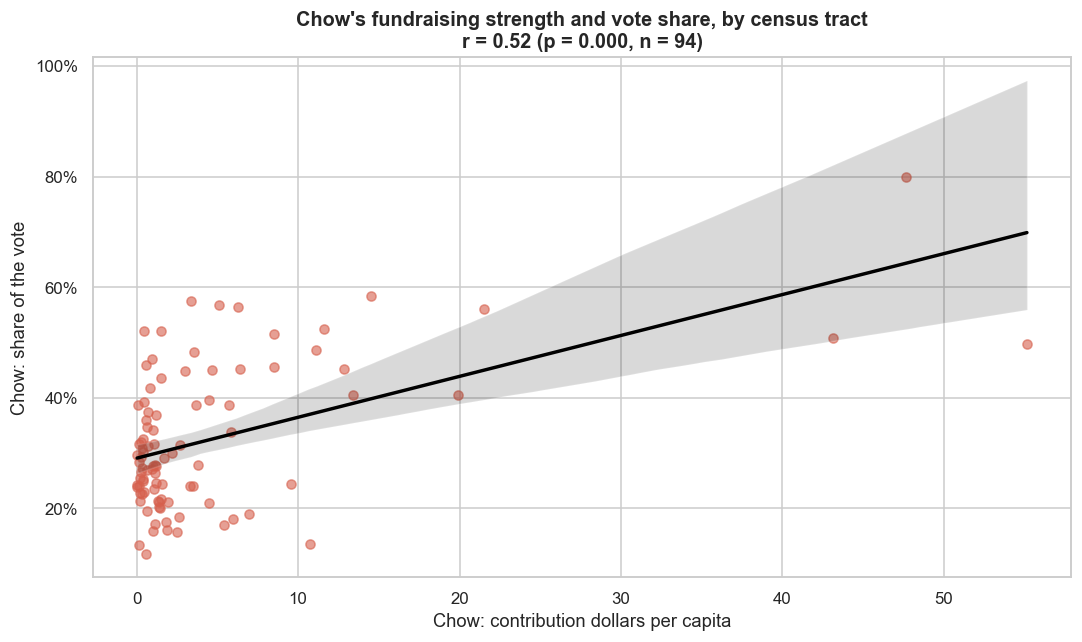

In [44]:
votes_2023 = gpd.read_file(VOTES_2023_CT_GEOJSON)
votes_2023["ctuid_norm"] = votes_2023["ctuid2021"].apply(normalize_ctuid)

fundraising_vs_votes = chow_ct.loc[chow_ct["n_unique_donors"] > 0].merge(
    votes_2023[["ctuid_norm", "pctchow_olivia2023", "pctbailao_ana2023"]], on="ctuid_norm", how="left"
).dropna(subset=["pctchow_olivia2023"])

r, p = stats.pearsonr(fundraising_vs_votes["dollars_per_capita"], fundraising_vs_votes["pctchow_olivia2023"])
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.regplot(data=fundraising_vs_votes, x="dollars_per_capita", y="pctchow_olivia2023", ax=ax,
            scatter_kws={"alpha": 0.6, "color": REPEAT_HIGHLIGHT_COLOR}, line_kws={"color": "black"})
ax.set_xlabel("Chow: contribution dollars per capita")
ax.set_ylabel("Chow: share of the vote")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title(f"Chow's fundraising strength and vote share, by census tract\nr = {r:.2f} (p = {p:.3f}, n = {len(fundraising_vs_votes)})")
plt.tight_layout()
plt.show()


There's a real, moderate relationship (r = 0.52): census tracts that gave Chow more money per
capita also tended to give her a higher vote share. But it's far from 1:1 — plenty of tracts that
gave her almost no money still delivered her 20-50% of the vote. That's consistent with
everything above: **Chow's financial constituency was narrower and more concentrated than her
electoral constituency.** We don't extend this into a full donor-base-vs-voter-base map for other
candidates or for council races — this is meant as a brief, low-effort check given data already in
the project, not a full study.

### Data-story potential — Part 9

**Promising but needs more work.** The correlation is real and the underlying data (official vote
shares already joined to CT geometry) required almost no extra effort to use, which is a point in
its favour. But a single scatterplot for a single candidate is a thin basis for a standalone
story angle; it would need at least one more contrasting candidate and a map (not just a
scatterplot) before it stood on its own.


# Potential Data Story Angles

Five candidate narratives came out of this exploration with enough evidence to assess honestly.

---

### 1. Toronto's political money comes from a small, wealthy slice of the city

**Claim:** Regardless of which candidate you look at, political contributions cluster hard in a
handful of central, high-income neighbourhoods (Rosedale, Forest Hill, the Annex, Yonge-
Eglinton) — while nearly every Toronto postal area participates *at all*, participation is not
the same as the money being spread evenly.

**Strongest evidence:** Part 3's choropleth maps and top-tract ranking; the correlation heatmap,
scatterplots, and small regression in Part 5 (education and racialized share are the strongest
independent predictors, R² ≈ 0.46).

**Strongest graphics:** the Part 3 $-per-capita and donors-per-1,000 maps; the Part 5 scatterplot
grid and correlation heatmap.

**Election(s)/candidates:** both 2022 council and 2023 mayor, pooled.

**2026 relevance:** frames the financial landscape every 2026 candidate — Chow included — is
raising money into.

**Caveats:** FSA-resolution geocoding (Part 3); ecological, not individual-level, demographics
(Part 5); the underlying regression is small and exploratory, not causal.

**Assessment: Strong.**

---

### 2. Chow raised less money than Bailão, but a far bigger, broader donor base

**Claim:** Ana Bailão out-raised Olivia Chow in total 2023 mayoral dollars (~$2.1M vs. ~$1.47M),
but Chow's donor base was more than double the size (3,214 vs. 1,274 unique donors) and reached
nearly every Toronto postal area within weeks, while Bailão's fundraising was a single large early
spike that plateaued earlier and narrower.

**Strongest evidence:** Part 6's cumulative-dollars, cumulative-donors, and geographic-reach line
charts; Part 2's fundraising landscape.

**Strongest graphics:** the Part 6 cumulative dollars/donors pair and the weekly-fundraising line
chart.

**Election(s)/candidates:** 2023 mayor — Chow vs. Bailão.

**2026 relevance:** direct and central — this is Olivia Chow's own historical fundraising
signature heading into her 2026 mayoral run.

**Caveats:** one election, one comparison pair; "broader donor base" is not the same as "broader
vote base," though Part 9 suggests some real relationship between the two.

**Assessment: Strong.**

---

### 3. Council candidates differ dramatically in how locally rooted their money is

**Claim:** Some 2022 council candidates raised the bulk of their money from inside their own ward;
others raised most of it from elsewhere in Toronto or beyond — and the four priority 2026 repeat
candidates span nearly that entire range themselves (Matlow most local, Bradford least local among
the three with a stable donor base; Holyday's tiny, nearly all-family donor base is a different
story again).

**Strongest evidence:** Part 4's ranked local-share bar charts; Part 8's compact repeat-candidate
comparison table.

**Strongest graphics:** the Part 4 "most and least ward-local" ranked bars (both dollar- and
donor-based versions).

**Election(s)/candidates:** 2022 council, especially Bradford, Bravo, Matlow, Holyday.

**2026 relevance:** direct — describes the kind of donor network each returning councillor brings
into 2026.

**Caveats:** FSA-centroid ward assignment can misclassify donors near ward boundaries; Holyday's
numbers rest on only 6 donors.

**Assessment: Strong.**

---

### 4. Specific council donor networks fed specific 2023 mayoral campaigns

**Claim:** Roughly a third of Bravo's and Malik's 2022 donors also gave to Chow in 2023, while
Grimes's, Burnside's, and Nunziata's donors overlapped more with Bailão — a real, named link
between council-level and mayoral-level fundraising coalitions, on top of Bradford's and Matlow's
own donors substantially funding their own (25% and 53%, respectively) mayoral runs.

**Strongest evidence:** Part 7's overlap heatmap and the Bradford-vs-Matlow retention bars.

**Strongest graphics:** the Part 7 candidate-by-candidate overlap heatmap.

**Election(s)/candidates:** 2022 council (Bravo, Malik, Grimes, Burnside, Nunziata, Bradford,
Matlow) linked to 2023 mayor (Chow, Bailão).

**2026 relevance:** suggests which existing donor coalitions could plausibly consolidate behind
which 2026 candidates, though this is necessarily speculative extrapolation.

**Caveats:** conservative name+postal-code matching under-counts true overlap; this describes
donor counts, not dollars, and is not a vote-transfer claim.

**Assessment: Strong, with the matching-method caveat kept front and centre.**

---

### 5. Financial constituencies and demographic profiles vary more by ward than by mayoral candidate

**Claim:** The 8 major 2023 mayoral candidates' donor bases look demographically similar to each
other (all skew wealthy/educated/non-racialized relative to Toronto) — but two 2026 council
repeat candidates, Bravo and Bradford/Matlow, show real demographic separation, with Bravo's donor
base looking close to an average Toronto tract and the other two's looking like Toronto's
wealthiest.

**Strongest evidence:** Part 5B's two dot-profile charts (mayoral vs. council).

**Strongest graphics:** the council version of the demographic dot-profile plot, since it's where
the real separation shows up.

**Election(s)/candidates:** 2022 council (Bravo vs. Bradford/Matlow); 2023 mayor (all majors, as
a "they're all similar" contrast case).

**2026 relevance:** moderate — supports a "different councillors, different financial bases"
framing, but the flagship 2026 story (mayor) is the case where this angle is *weakest*.

**Caveats:** ecological description only; the mayoral half of this finding is really a
non-finding (convergence, not divergence), which should be stated plainly rather than stretched.

**Assessment: Promising but needs more work** — worth one more contrasting council candidate pair
before treating this as a headline.

---

## Recommendation

The two strongest, most publication-ready directions are **#1 (Toronto's donor geography is
unequal and concentrated in wealthy neighbourhoods)** and **#2 (Chow's broad-but-not-largest
2023 fundraising base, heading into 2026)**. Both are visually strong (a map and a line-chart pair
respectively), both survive multiple independent checks in this notebook, and both connect
directly to a general-interest reader's likely questions about the 2026 election. **#3 and #4**
(local-rootedness and cross-election donor networks) are strong secondary material — either could
anchor a companion piece specifically about the returning council candidates, especially since #4
gives that companion piece a genuinely new, previously unpublished-feeling finding (the donor-
network overlap heatmap). **#5** needs another candidate pair before it's ready to lead anything.
